In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import tensorflow as tf
from numpy import mean
from numpy import std
import matplotlib.pyplot as plt
from matplotlib import pyplot
import pylab
import seaborn as sns
import plotly.express as px
import scipy.stats as stats
#Import models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import classification_report
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/default of credit card clients.xlsx")

In [3]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')

In [4]:
df.shape

(30000, 25)

In [5]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [6]:
#renaming for better convinience
df['IsDefaulter'] =df ['default payment next month']
df.drop('default payment next month',axis = 1)
# df.rename({'default payment next month' : 'IsDefaulter'}, inplace=True)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,IsDefaulter
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000,1,3,1,39,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,29998,30000,1,2,2,37,4,3,2,-1,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,29999,80000,1,3,1,41,1,-1,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


In [7]:
df.isnull().sum()

,0
ID,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.drop_duplicates(inplace = True)
df.shape

(30000, 26)

In [10]:
for col in df.select_dtypes(include=["object"]):
      print(col)

In [11]:
for col in df.select_dtypes(include=["number"]):
      print(col)

ID
LIMIT_BAL
SEX
EDUCATION
MARRIAGE
AGE
PAY_0
PAY_2
PAY_3
PAY_4
PAY_5
PAY_6
BILL_AMT1
BILL_AMT2
BILL_AMT3
BILL_AMT4
BILL_AMT5
BILL_AMT6
PAY_AMT1
PAY_AMT2
PAY_AMT3
PAY_AMT4
PAY_AMT5
PAY_AMT6
default payment next month
IsDefaulter


In [12]:
df.drop(columns = ["ID", "default payment next month"], inplace=True)

In [13]:
df.dropna(thresh = 13, inplace = True)
df.isnull().sum()

,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0
PAY_5,0


In [14]:
df.shape

(30000, 24)

In [15]:
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,IsDefaulter
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   LIMIT_BAL    30000 non-null  int64
 1   SEX          30000 non-null  int64
 2   EDUCATION    30000 non-null  int64
 3   MARRIAGE     30000 non-null  int64
 4   AGE          30000 non-null  int64
 5   PAY_0        30000 non-null  int64
 6   PAY_2        30000 non-null  int64
 7   PAY_3        30000 non-null  int64
 8   PAY_4        30000 non-null  int64
 9   PAY_5        30000 non-null  int64
 10  PAY_6        30000 non-null  int64
 11  BILL_AMT1    30000 non-null  int64
 12  BILL_AMT2    30000 non-null  int64
 13  BILL_AMT3    30000 non-null  int64
 14  BILL_AMT4    30000 non-null  int64
 15  BILL_AMT5    30000 non-null  int64
 16  BILL_AMT6    30000 non-null  int64
 17  PAY_AMT1     30000 non-null  int64
 18  PAY_AMT2     30000 non-null  int64
 19  PAY_AMT3     30000 non-null  int64
 20  PAY_AM

In [17]:
df.describe()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,IsDefaulter
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


<Axes: xlabel='IsDefaulter', ylabel='count'>

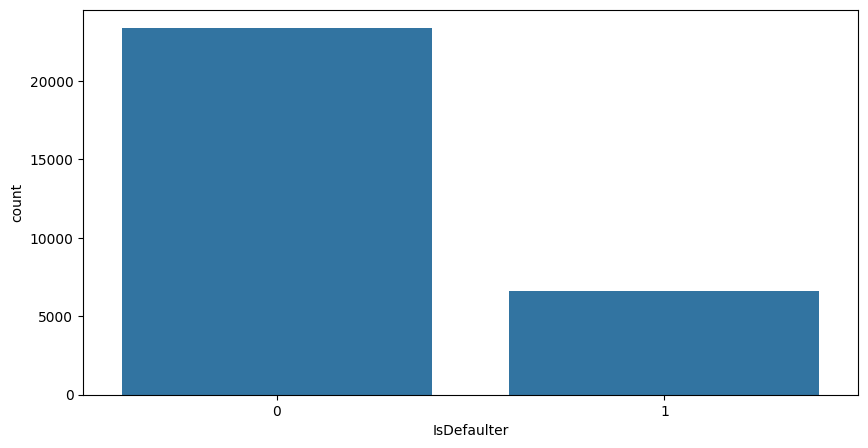

In [18]:
plt.figure(figsize=(10,5))
sns.countplot(x = 'IsDefaulter', data = df)

In [19]:
df['IsDefaulter'].value_counts()

,count
IsDefaulter,
0,23364
1,6636


In [20]:
df['SEX'].value_counts()

,count
SEX,
2,18112
1,11888


In [21]:
df['EDUCATION'].value_counts()

,count
EDUCATION,
2,14030
1,10585
3,4917
5,280
4,123
6,51
0,14


In [22]:
fil = (df['EDUCATION'] == 5) | (df['EDUCATION'] == 6) | (df['EDUCATION'] == 0)
df.loc[fil, 'EDUCATION'] = 4
df['EDUCATION'].value_counts()

,count
EDUCATION,
2,14030
1,10585
3,4917
4,468


In [23]:
df['MARRIAGE'].value_counts()

,count
MARRIAGE,
2,15964
1,13659
3,323
0,54


In [24]:
fil = df['MARRIAGE'] == 0
df.loc[fil, 'MARRIAGE'] = 3
df['MARRIAGE'].value_counts()

,count
MARRIAGE,
2,15964
1,13659
3,377


In [25]:
categorical_features = ['SEX', 'EDUCATION', 'MARRIAGE']

In [26]:
df_cat = df[categorical_features]
df_cat['Defaulter'] = df['IsDefaulter']

In [27]:
df_cat.replace({'SEX': {1 : 'MALE', 2 : 'FEMALE'}, 'EDUCATION' : {1 : 'graduate school', 2 : 'university', 3 : 'high school', 4 : 'others'}, 'MARRIAGE' : {1 : 'married', 2 : 'single', 3 : 'others'}}, inplace = True)

<Figure size 1000x500 with 0 Axes>

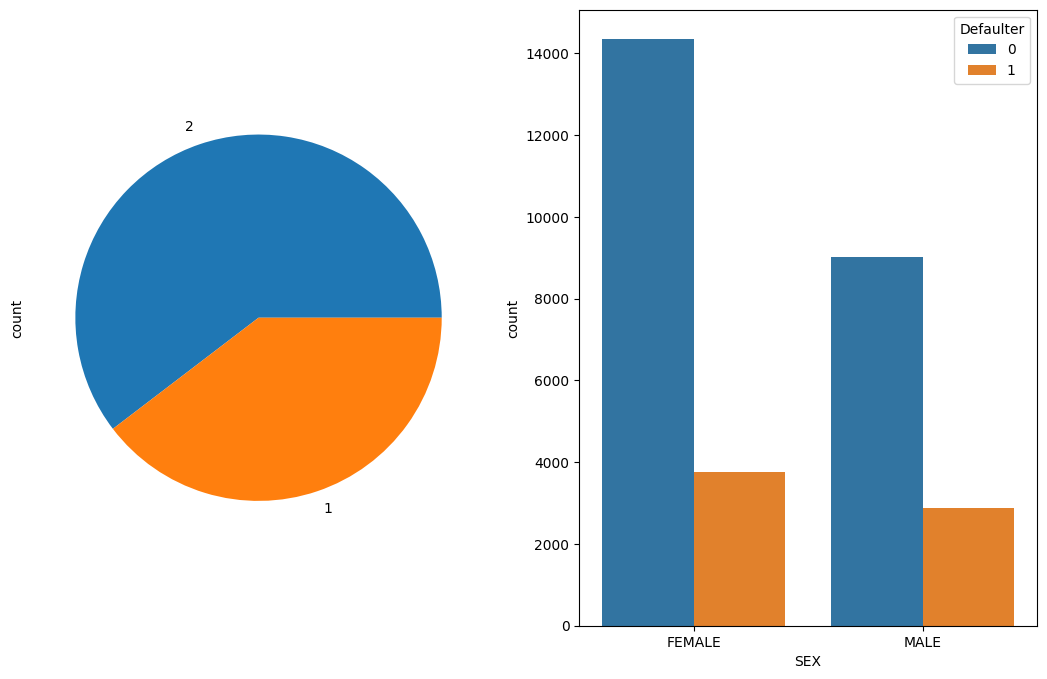

<Figure size 1000x500 with 0 Axes>

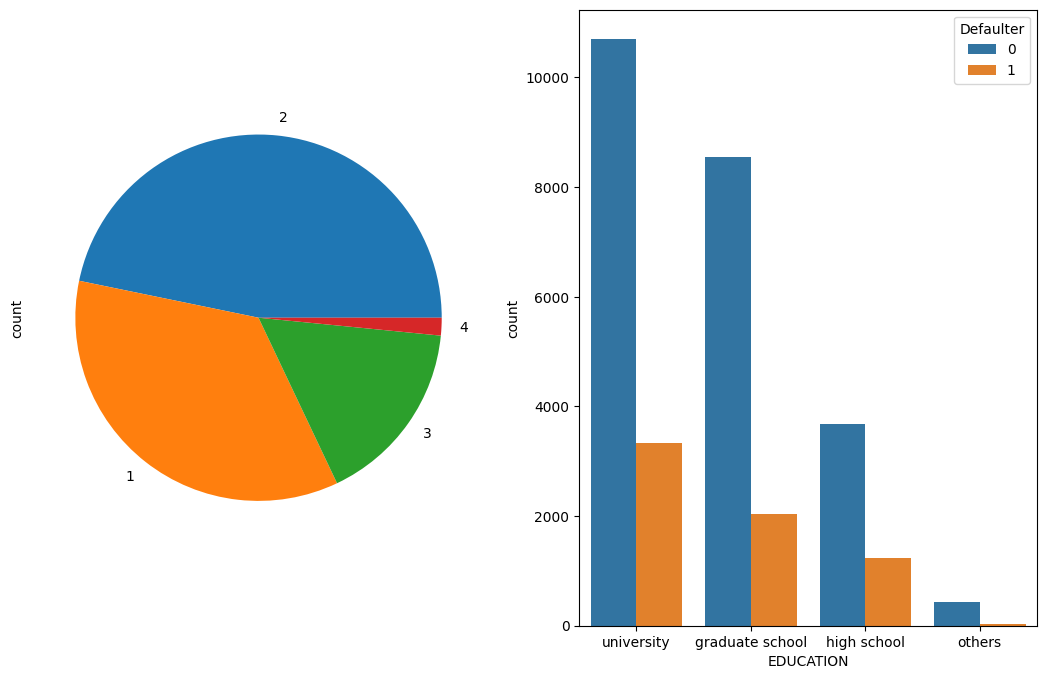

<Figure size 1000x500 with 0 Axes>

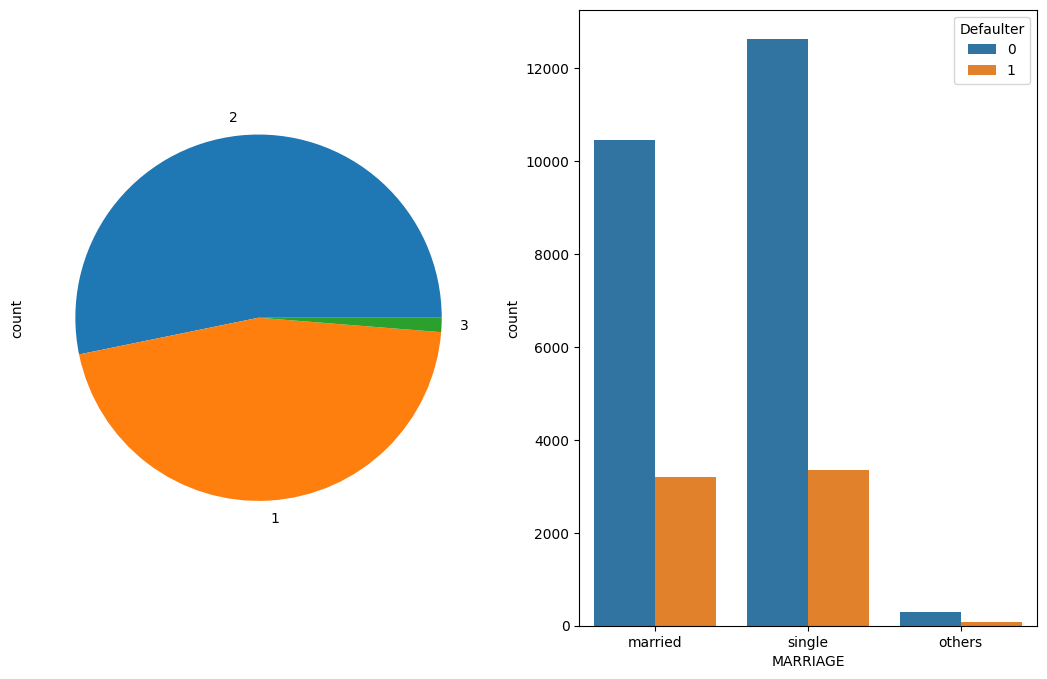

In [28]:
for col in categorical_features:
  plt.figure(figsize=(10,5))
  fig, axes = plt.subplots(ncols=2,figsize=(13,8))
  df[col].value_counts().plot(kind="pie",ax = axes[0],subplots=True)
  sns.countplot(x = col, hue = 'Defaulter', data = df_cat)

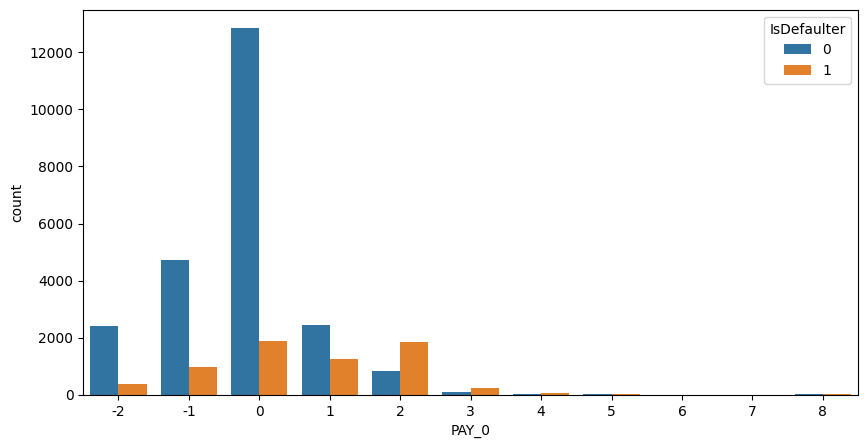

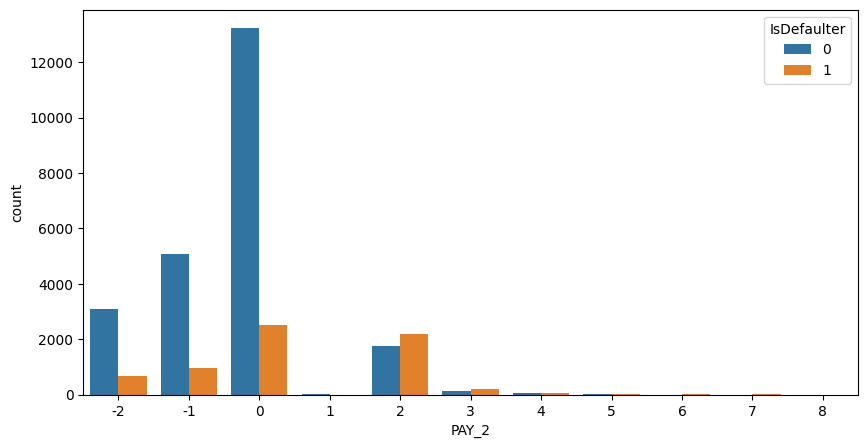

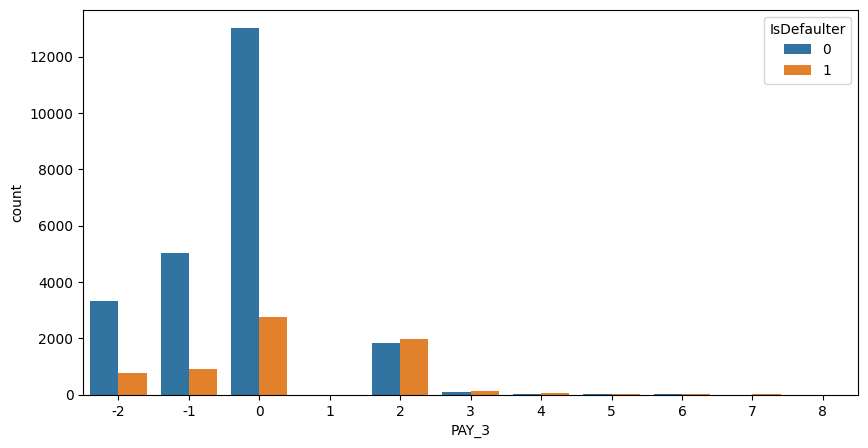

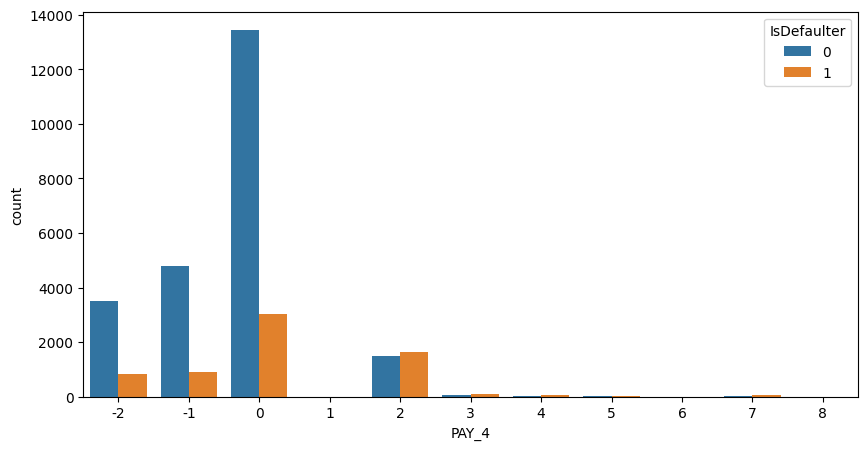

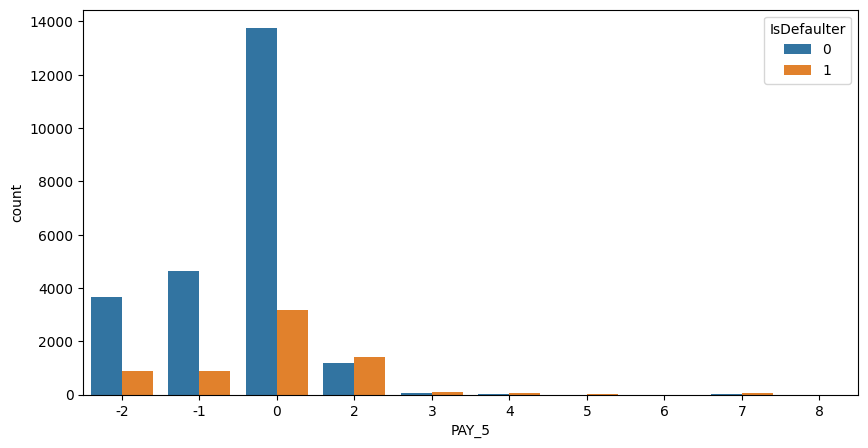

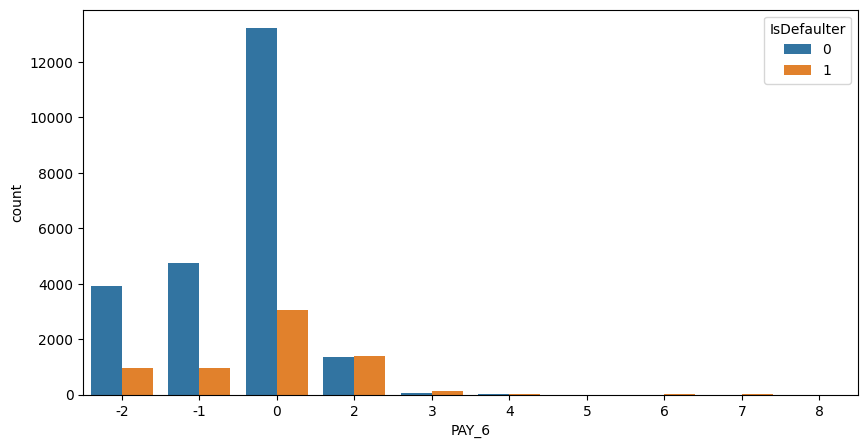

In [29]:
pay_col = ['PAY_0',	'PAY_2',	'PAY_3',	'PAY_4',	'PAY_5', 'PAY_6']
for col in pay_col:
  plt.figure(figsize=(10,5))
  sns.countplot(x = col, hue = 'IsDefaulter', data = df)

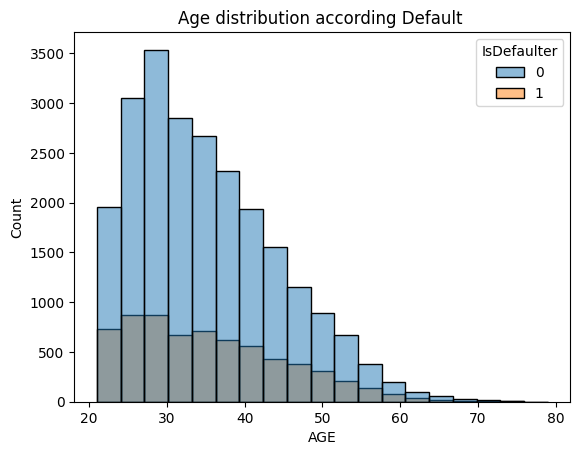

In [30]:
sns.histplot(data=df, x="AGE", hue="IsDefaulter", binwidth=3)
plt.title("Age distribution according Default ")
plt.show()

In [31]:
df['AGE'].value_counts()

,count
AGE,
29,1605
27,1477
28,1409
30,1395
26,1256
31,1217
25,1186
34,1162
32,1158


In [32]:
df['AGE']=df['AGE'].astype('int')

<Axes: xlabel='AGE', ylabel='count'>

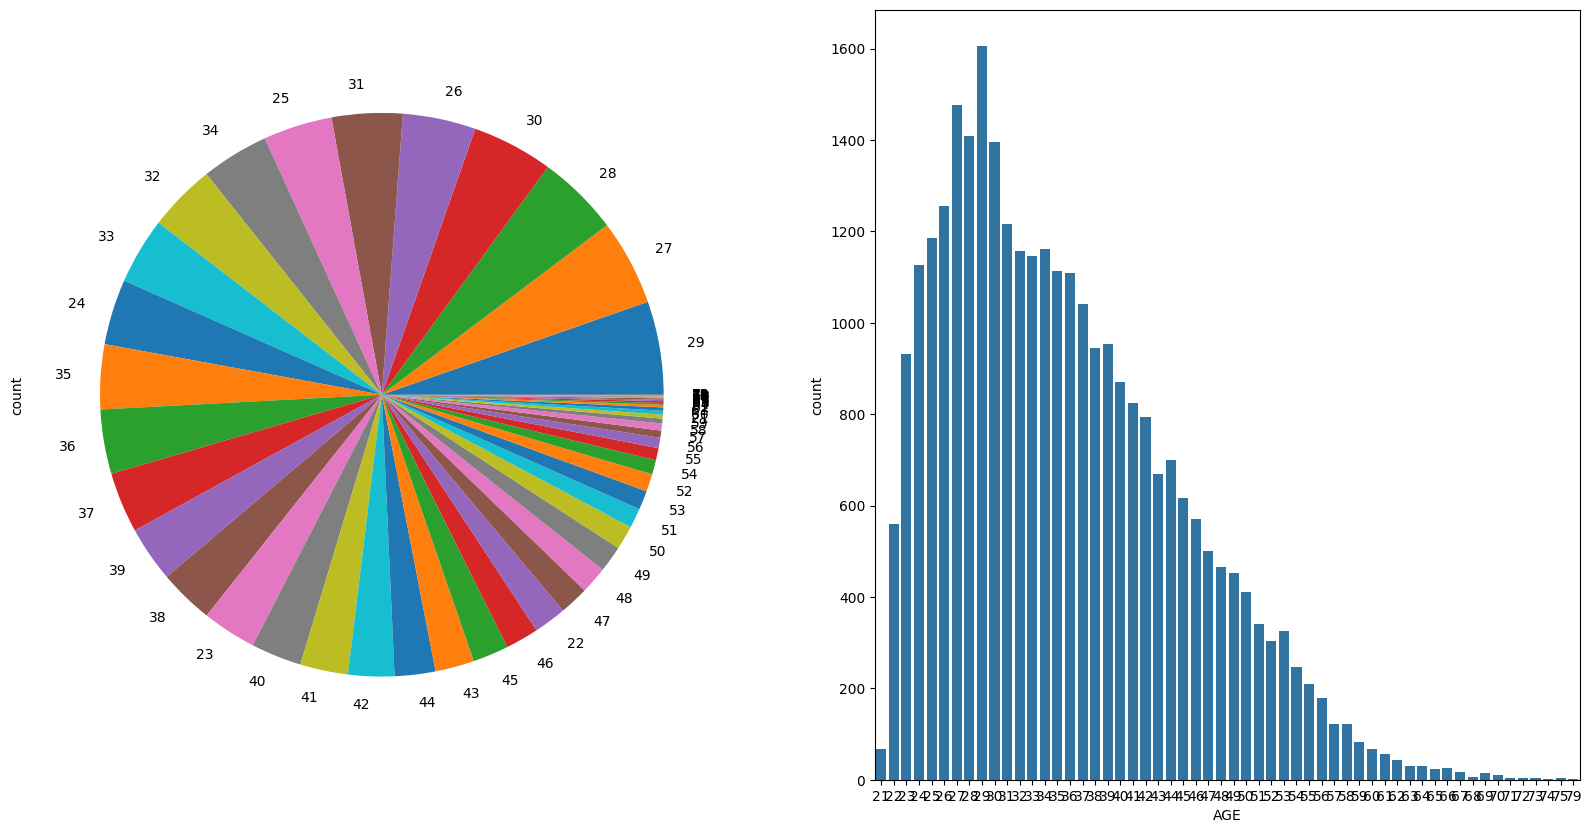

In [33]:
fig, axes = plt.subplots(ncols=2,figsize=(20,10))
Day_df=df['AGE'].value_counts().reset_index()
df['AGE'].value_counts().plot(kind="pie",ax = axes[0],subplots=True)
sns.barplot(x='AGE',y='count',data=Day_df,ax = axes[1],orient='v')

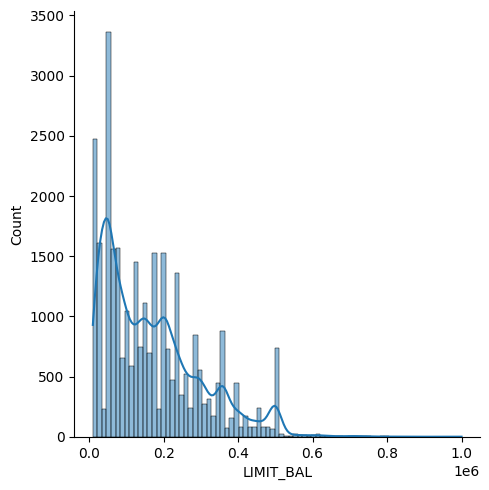

In [34]:
sns.displot(df.LIMIT_BAL, kde=True)

<Axes: >

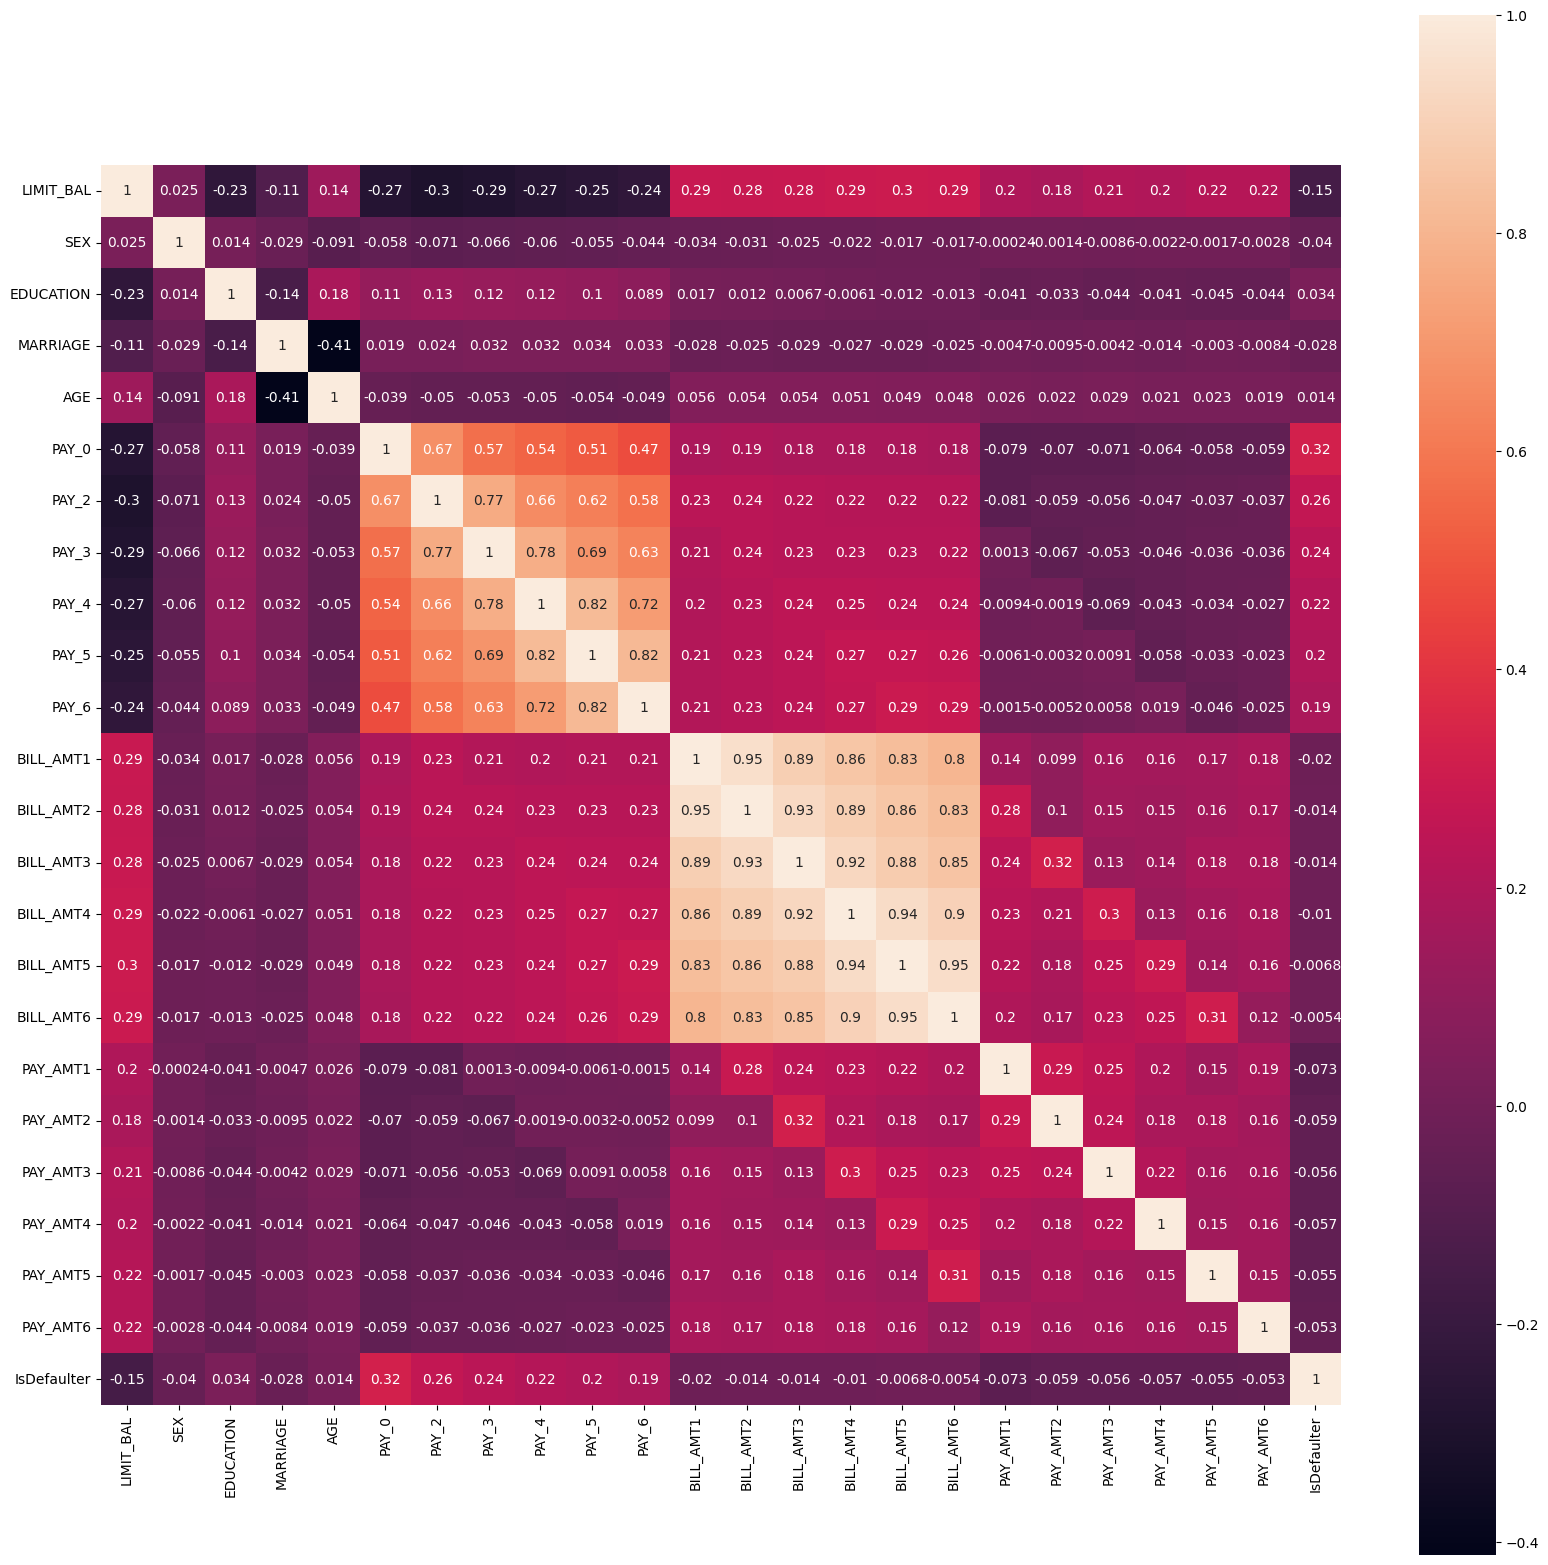

In [35]:
plt.figure(figsize = (20,20))
sns.heatmap(df.corr(),annot = True,square = True)

In [36]:
X = df.drop(labels='IsDefaulter', axis=1)

In [37]:
X.shape

(30000, 23)

In [38]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 23 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LIMIT_BAL  30000 non-null  int64
 1   SEX        30000 non-null  int64
 2   EDUCATION  30000 non-null  int64
 3   MARRIAGE   30000 non-null  int64
 4   AGE        30000 non-null  int64
 5   PAY_0      30000 non-null  int64
 6   PAY_2      30000 non-null  int64
 7   PAY_3      30000 non-null  int64
 8   PAY_4      30000 non-null  int64
 9   PAY_5      30000 non-null  int64
 10  PAY_6      30000 non-null  int64
 11  BILL_AMT1  30000 non-null  int64
 12  BILL_AMT2  30000 non-null  int64
 13  BILL_AMT3  30000 non-null  int64
 14  BILL_AMT4  30000 non-null  int64
 15  BILL_AMT5  30000 non-null  int64
 16  BILL_AMT6  30000 non-null  int64
 17  PAY_AMT1   30000 non-null  int64
 18  PAY_AMT2   30000 non-null  int64
 19  PAY_AMT3   30000 non-null  int64
 20  PAY_AMT4   30000 non-null  int64
 21  PAY_AMT5   3

In [39]:
y = df['IsDefaulter']

In [40]:
y.shape

(30000,)

Feature 1 score: 724.0685392611731 p-value: 1.3022439532662e-157
Feature 2 score: 47.97885434763421 p-value: 4.395248803318711e-12
Feature 3 score: 34.39599861167496 p-value: 4.543558404985928e-09
Feature 4 score: 22.82676851892876 p-value: 1.7811700407228418e-06
Feature 5 score: 5.788555824671978 p-value: 0.016136845890286453
Feature 6 score: 3537.7149696267284 p-value: 0.0
Feature 7 score: 2239.169135846616 p-value: 0.0
Feature 8 score: 1757.4664440265149 p-value: 0.0
Feature 9 score: 1476.8459673526877 p-value: 1.899296587e-315
Feature 10 score: 1304.5911757099395 p-value: 1.1266079544986417e-279
Feature 11 score: 1085.4024851202666 p-value: 7.296740483293014e-234
Feature 12 score: 11.58053151629379 p-value: 0.0006673295491269827
Feature 13 score: 6.044237892358651 p-value: 0.013957362392557893
Feature 14 score: 5.944387708459984 p-value: 0.014769982710844272
Feature 15 score: 3.0947451847823597 p-value: 0.07855564157726781
Feature 16 score: 1.371087396629338 p-value: 0.241634442915

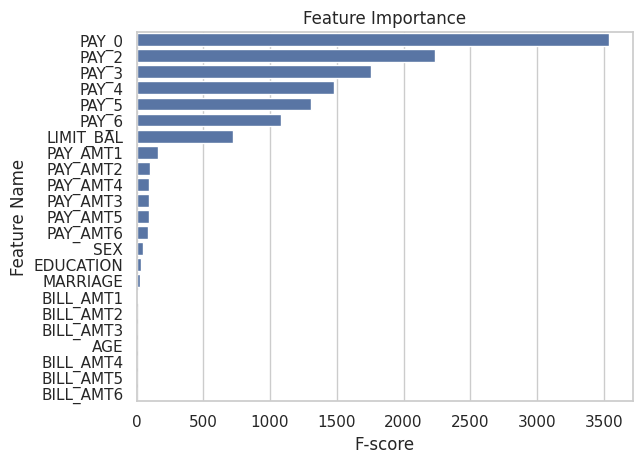

In [41]:
from sklearn.feature_selection import f_regression
scores, p_values = f_regression(X, y)
# Print the results
for i in range(len(scores)):
    print("Feature", i+1, "score:", scores[i], "p-value:", p_values[i])

feature_names = list(X.columns)

# Sort the scores and feature names in descending order
sorted_indices = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)
scores = [scores[i] for i in sorted_indices]
feature_names = [feature_names[i] for i in sorted_indices]

# Create a bar plot of feature importance
sns.set(style="whitegrid")
sns.barplot(x=scores, y=feature_names, color="b")

# Set the plot title and axes labels
plt.title("Feature Importance")
plt.xlabel("F-score")
plt.ylabel("Feature Name")

# Show the plot
plt.show()

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=15)

In [43]:
y_train.value_counts()

,count
IsDefaulter,
0,18738
1,5262


In [44]:
y.value_counts()

,count
IsDefaulter,
0,23364
1,6636


In [45]:
y_test.value_counts()

,count
IsDefaulter,
0,4626
1,1374


In [46]:
X_train.shape

(24000, 23)

In [47]:
X_test.shape

(6000, 23)

In [48]:
X_train[:10]

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
12086,50000,1,1,1,42,0,0,0,0,0,...,38680,29664,29057,29083,1850,1507,1100,1200,1116,2900
26087,50000,2,2,1,37,0,0,0,0,0,...,48923,39210,30515,27861,10000,2131,1910,1410,1159,1050
27778,50000,2,2,1,24,0,0,0,0,0,...,33441,32697,33693,33029,10000,2000,1500,3000,1500,9
10933,330000,2,1,2,24,0,0,0,0,0,...,317997,274132,267622,261246,12500,10882,9902,10000,10000,17629
4123,120000,2,2,1,40,-2,-2,-2,-1,0,...,0,3663,3663,0,0,0,3663,0,0,0
20380,50000,1,3,1,23,0,0,0,0,0,...,46653,43143,19003,-317,2100,3260,1200,1000,0,16628
26857,260000,1,1,1,40,0,0,-1,-1,-1,...,3923,9059,3360,3657,7590,3945,31086,3377,3667,493
25964,120000,2,1,2,29,0,0,0,2,0,...,11793,11307,14102,15871,3000,2691,0,3000,2000,0
26925,130000,1,2,3,34,2,2,2,0,0,...,132249,132416,131959,128375,11243,0,5600,5150,5100,4512
12120,150000,1,3,1,27,2,2,2,2,0,...,192342,189717,195670,198611,10000,8000,2000,9000,8000,110000


In [49]:
# Trying without Normalization

In [50]:
# prepare the cross-validation procedure
from sklearn.datasets import make_classification
cv = KFold(n_splits=10, random_state=1, shuffle=True)

In [51]:
#Applying Logistic Regression

In [52]:
# evaluate a Logistic Regression model using k-fold cross-validation
# create model
LR = LogisticRegression()
# evaluate model
scores_LR = cross_val_score(LR, X, y, scoring='accuracy', cv=cv, n_jobs=-1)
# report performance
print('Accuracy: %.3f (%.3f)' % (mean(scores_LR), std(scores_LR)))

Accuracy: 0.779 (0.009)


In [53]:
LR = LogisticRegression()
LR.fit(X_train, y_train)

y_pred_LR = LR.predict(X_test)

cl_rep_LR = classification_report(y_test,y_pred_LR)
print(cl_rep_LR)

              precision    recall  f1-score   support

           0       0.77      1.00      0.87      4626
           1       0.00      0.00      0.00      1374

    accuracy                           0.77      6000
   macro avg       0.39      0.50      0.44      6000
weighted avg       0.59      0.77      0.67      6000



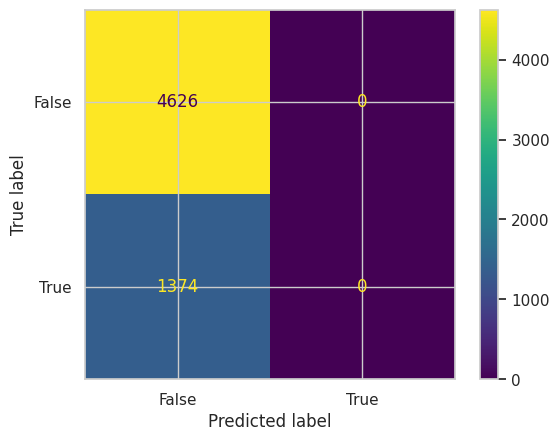

In [54]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred_LR)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

In [55]:
Specificity = metrics.recall_score(y_test, y_pred_LR, pos_label=0)
Accuracy = metrics.accuracy_score(y_test, y_pred_LR)
Precision = metrics.precision_score(y_test, y_pred_LR)
Sensitivity_recall = metrics.recall_score(y_test, y_pred_LR)
F1_score = metrics.f1_score(y_test, y_pred_LR)
auc_roc_score = roc_auc_score(y_test, y_pred_LR)
print({"Accuracy":Accuracy})
print({"Precision":Precision,})
print({"Sensitivity_recall":Sensitivity_recall,})
print({"Specificity":Specificity,})
print({"F1_score":F1_score})
print({"AUC-ROC":roc_auc_score(y_test, y_pred_LR)})

{'Accuracy': 0.771}
{'Precision': 0.0}
{'Sensitivity_recall': 0.0}
{'Specificity': 1.0}
{'F1_score': 0.0}
{'AUC-ROC': np.float64(0.5)}


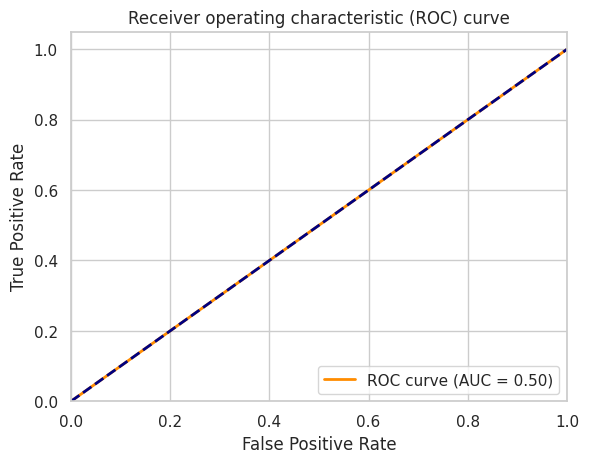

In [56]:
# y_test: true binary labels (0 or 1)
# y_pred: predicted binary labels (0 or 1)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_LR)
roc_auc = auc(fpr, tpr)

plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange', lw=lw, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic (ROC) curve')
plt.legend(loc="lower right")
plt.show()

In [57]:
#Applying Extra Tree Classifier

In [58]:
# evaluate a Extra Tree Classifier model using k-fold cross-validation
# create model
ETC = ExtraTreesClassifier()
# evaluate model
scores_ETC = cross_val_score(ETC, X, y, scoring='accuracy', cv=cv, n_jobs=-1)
# report performance
print('Accuracy: %.3f (%.3f)' % (mean(scores_ETC), std(scores_ETC)))

Accuracy: 0.810 (0.008)


In [59]:
ETC = ExtraTreesClassifier()
ETC.fit(X_train, y_train)

y_pred_ETC = ETC.predict(X_test)

cl_rep_ETC = classification_report(y_test,y_pred_ETC)
print(cl_rep_ETC)

              precision    recall  f1-score   support

           0       0.83      0.94      0.88      4626
           1       0.64      0.36      0.46      1374

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000



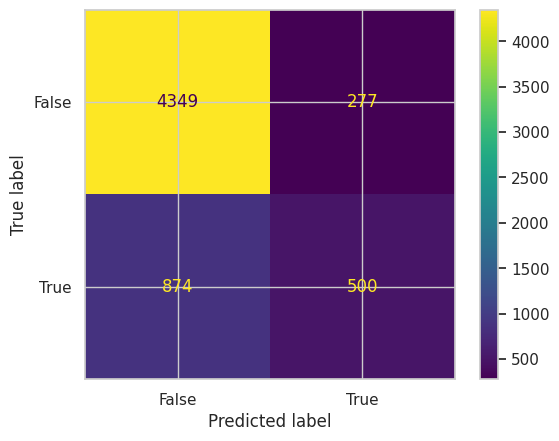

In [60]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred_ETC)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

In [61]:
Specificity = metrics.recall_score(y_test, y_pred_ETC, pos_label=0)
Accuracy = metrics.accuracy_score(y_test, y_pred_ETC)
Precision = metrics.precision_score(y_test, y_pred_ETC)
Sensitivity_recall = metrics.recall_score(y_test, y_pred_ETC)
F1_score = metrics.f1_score(y_test, y_pred_ETC)
print({"Accuracy":Accuracy})
print({"Precision":Precision,})
print({"Sensitivity_recall":Sensitivity_recall,})
print({"Specificity":Specificity,})
print({"F1_score":F1_score})

{'Accuracy': 0.8081666666666667}
{'Precision': 0.6435006435006435}
{'Sensitivity_recall': 0.363901018922853}
{'Specificity': 0.9401210549070471}
{'F1_score': 0.46490004649000466}


In [62]:
#Applying Decision Tree Classifier

In [63]:
# evaluate a Decision Tree Classifier model using k-fold cross-validation
# create model
DTC = DecisionTreeClassifier()
# evaluate model
scores_DTC = cross_val_score(DTC, X, y, scoring='accuracy', cv=cv, n_jobs=-1)
# report performance
print('Accuracy: %.3f (%.3f)' % (mean(scores_DTC), std(scores_DTC)))

Accuracy: 0.728 (0.008)


In [64]:
DTC = DecisionTreeClassifier()
DTC.fit(X_train, y_train)

y_pred_DTC = DTC.predict(X_test)
cl_rep_DTC = classification_report(y_test,y_pred_DTC)
print(cl_rep_DTC)

              precision    recall  f1-score   support

           0       0.83      0.82      0.82      4626
           1       0.41      0.43      0.42      1374

    accuracy                           0.73      6000
   macro avg       0.62      0.62      0.62      6000
weighted avg       0.73      0.73      0.73      6000



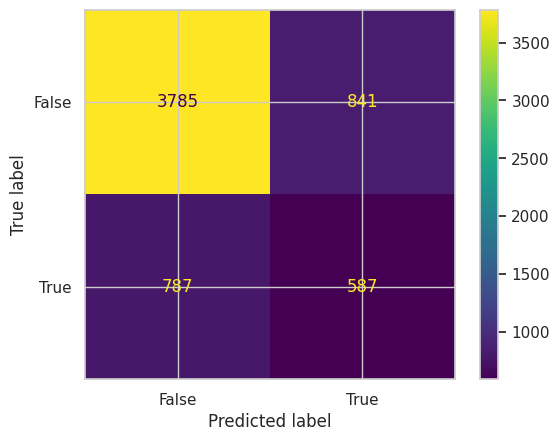

In [65]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred_DTC)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

In [66]:
Specificity = metrics.recall_score(y_test, y_pred_DTC, pos_label=0)
Accuracy = metrics.accuracy_score(y_test, y_pred_DTC)
Precision = metrics.precision_score(y_test, y_pred_DTC)
Sensitivity_recall = metrics.recall_score(y_test, y_pred_DTC)
F1_score = metrics.f1_score(y_test, y_pred_DTC)
print({"Accuracy":Accuracy})
print({"Precision":Precision,})
print({"Sensitivity_recall":Sensitivity_recall,})
print({"Specificity":Specificity,})
print({"F1_score":F1_score})

{'Accuracy': 0.7286666666666667}
{'Precision': 0.4110644257703081}
{'Sensitivity_recall': 0.4272197962154294}
{'Specificity': 0.8182014699524427}
{'F1_score': 0.4189864382583869}


In [67]:
# Trying after applying Standard Scalar for normalization

In [68]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)
X_train.shape

(24000, 23)

In [69]:
y_train.value_counts()

,count
IsDefaulter,
0,18738
1,5262


In [70]:
y.value_counts()

,count
IsDefaulter,
0,23364
1,6636


In [71]:
y_test.value_counts()

,count
IsDefaulter,
0,4626
1,1374


In [72]:
X_train.shape

(24000, 23)

In [73]:
X_test.shape

(6000, 23)

In [74]:
X_train[:10]

array([[-9.07149821e-01, -1.23458096e+00, -1.13207196e+00,
        -1.07329272e+00,  7.15213723e-01,  1.80663926e-02,
         1.15133903e-01,  1.39115445e-01,  1.87696970e-01,
         2.34447837e-01,  2.50511180e-01, -1.64150752e-02,
         4.69008995e-03, -1.19445574e-01, -2.11648724e-01,
        -1.84403579e-01, -1.65436371e-01, -2.27414633e-01,
        -1.83129180e-01, -2.34521353e-01, -2.26668176e-01,
        -2.44338650e-01, -1.31626095e-01],
       [-9.07149821e-01,  8.09991430e-01,  2.15499067e-01,
        -1.07329272e+00,  1.71879313e-01,  1.80663926e-02,
         1.15133903e-01,  1.39115445e-01,  1.87696970e-01,
         2.34447837e-01,  2.50511180e-01, -1.72195172e-01,
        -2.06251732e-02,  2.79800285e-02, -6.31405857e-02,
        -1.60343338e-01, -1.86059642e-01,  2.46523519e-01,
        -1.57326297e-01, -1.88517299e-01, -2.13411871e-01,
        -2.41472710e-01, -2.35116203e-01],
       [-9.07149821e-01,  8.09991430e-01,  2.15499067e-01,
        -1.07329272e+00, -1.2

In [75]:
# prepare the cross-validation procedure
from sklearn.datasets import make_classification
cv = KFold(n_splits=10, random_state=1, shuffle=True)

In [76]:
#Applying Logistic Regression

In [77]:
# evaluate a Logistic Regression model using k-fold cross-validation
# create model
LR = LogisticRegression()
# evaluate model
scores_LR = cross_val_score(LR, X, y, scoring='accuracy', cv=cv, n_jobs=-1)
# report performance
print('Accuracy: %.3f (%.3f)' % (mean(scores_LR), std(scores_LR)))

Accuracy: 0.779 (0.009)


In [78]:
LR = LogisticRegression()
LR.fit(X_train, y_train)

y_pred_LR = LR.predict(X_test)

cl_rep_LR = classification_report(y_test,y_pred_LR)
print(cl_rep_LR)

              precision    recall  f1-score   support

           0       0.81      0.98      0.88      4626
           1       0.73      0.23      0.34      1374

    accuracy                           0.80      6000
   macro avg       0.77      0.60      0.61      6000
weighted avg       0.79      0.80      0.76      6000



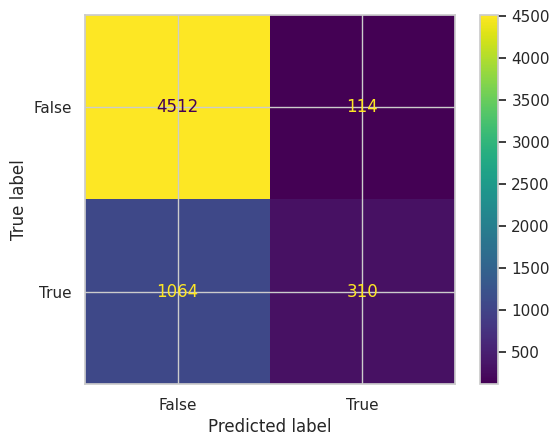

In [79]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred_LR)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

In [80]:
Specificity = metrics.recall_score(y_test, y_pred_LR, pos_label=0)
Specificity = metrics.recall_score(y_test, y_pred_LR, pos_label=1)
Accuracy = metrics.accuracy_score(y_test, y_pred_LR)
Precision = metrics.precision_score(y_test, y_pred_LR)
Sensitivity_recall = metrics.recall_score(y_test, y_pred_LR)
F1_score = metrics.f1_score(y_test, y_pred_LR)
print({"Accuracy":Accuracy})
print({"Precision":Precision,})
print({"Sensitivity_recall":Sensitivity_recall,})
print({"Specificity":Specificity,})
print({"F1_score":F1_score})

{'Accuracy': 0.8036666666666666}
{'Precision': 0.7311320754716981}
{'Sensitivity_recall': 0.22561863173216884}
{'Specificity': 0.22561863173216884}
{'F1_score': 0.3448275862068966}


In [81]:
#Applying Extra Tree Classifier

In [82]:
# evaluate a Extra Tree Classifier model using k-fold cross-validation
# create model
ETC = ExtraTreesClassifier()
# evaluate model
scores_ETC = cross_val_score(ETC, X, y, scoring='accuracy', cv=cv, n_jobs=-1)
# report performance
print('Accuracy: %.3f (%.3f)' % (mean(scores_ETC), std(scores_ETC)))

Accuracy: 0.811 (0.007)


In [83]:
ETC = ExtraTreesClassifier()
ETC.fit(X_train, y_train)

y_pred_ETC = ETC.predict(X_test)

cl_rep_ETC = classification_report(y_test,y_pred_ETC)
print(cl_rep_ETC)

              precision    recall  f1-score   support

           0       0.83      0.95      0.89      4626
           1       0.68      0.34      0.45      1374

    accuracy                           0.81      6000
   macro avg       0.75      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000



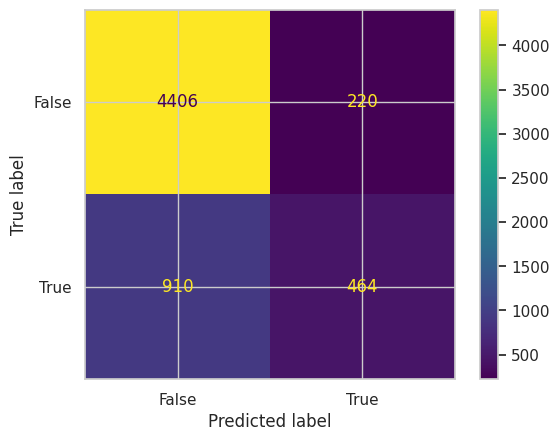

In [84]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred_ETC)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

In [85]:
Specificity = metrics.recall_score(y_test, y_pred_ETC, pos_label=0)
Accuracy = metrics.accuracy_score(y_test, y_pred_ETC)
Precision = metrics.precision_score(y_test, y_pred_ETC)
Sensitivity_recall = metrics.recall_score(y_test, y_pred_ETC)
F1_score = metrics.f1_score(y_test, y_pred_ETC)
print({"Accuracy":Accuracy})
print({"Precision":Precision,})
print({"Sensitivity_recall":Sensitivity_recall,})
print({"Specificity":Specificity,})
print({"F1_score":F1_score})

{'Accuracy': 0.8116666666666666}
{'Precision': 0.6783625730994152}
{'Sensitivity_recall': 0.33770014556040756}
{'Specificity': 0.9524427150886294}
{'F1_score': 0.4509232264334305}


In [86]:
#Applying Decision Tree Classifier

In [87]:
# evaluate a Decision Tree Classifier model using k-fold cross-validation
# create model
DTC = DecisionTreeClassifier()
# evaluate model
scores_DTC = cross_val_score(DTC, X, y, scoring='accuracy', cv=cv, n_jobs=-1)
# report performance
print('Accuracy: %.3f (%.3f)' % (mean(scores_DTC), std(scores_DTC)))

Accuracy: 0.725 (0.009)


In [88]:
DTC = DecisionTreeClassifier()
DTC.fit(X_train, y_train)

y_pred_DTC = DTC.predict(X_test)
cl_rep_DTC = classification_report(y_test,y_pred_DTC)
print(cl_rep_DTC)

              precision    recall  f1-score   support

           0       0.82      0.80      0.81      4626
           1       0.37      0.40      0.38      1374

    accuracy                           0.71      6000
   macro avg       0.59      0.60      0.59      6000
weighted avg       0.71      0.71      0.71      6000



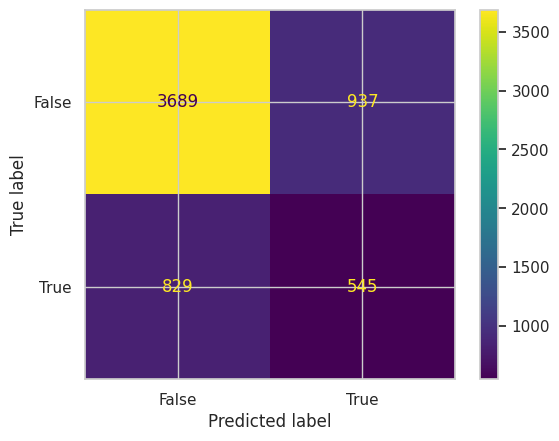

In [89]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred_DTC)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

In [90]:
Specificity = metrics.recall_score(y_test, y_pred_DTC, pos_label=0)
Accuracy = metrics.accuracy_score(y_test, y_pred_DTC)
Precision = metrics.precision_score(y_test, y_pred_DTC)
Sensitivity_recall = metrics.recall_score(y_test, y_pred_DTC)
F1_score = metrics.f1_score(y_test, y_pred_DTC)
print({"Accuracy":Accuracy})
print({"Precision":Precision,})
print({"Sensitivity_recall":Sensitivity_recall,})
print({"Specificity":Specificity,})
print({"F1_score":F1_score})

{'Accuracy': 0.7056666666666667}
{'Precision': 0.36774628879892035}
{'Sensitivity_recall': 0.39665211062590977}
{'Specificity': 0.7974492001729356}
{'F1_score': 0.38165266106442575}


In [91]:
#Mitigating Skewdness of Data

In [92]:
#Method1: Undersampling

In [93]:
# Class count
count_class_0, count_class_1 = df.IsDefaulter.value_counts()

# Divide by class
df_class_0 = df[df['IsDefaulter'] == 0]
df_class_1 = df[df['IsDefaulter'] == 1]

In [94]:
# Undersample 0-class and concat the DataFrames of both class
df_class_0_under = df_class_0.sample(count_class_1)
df_test_under = pd.concat([df_class_0_under, df_class_1], axis=0)

print('Random under-sampling:')
print(df_test_under.IsDefaulter.value_counts())

Random under-sampling:
IsDefaulter
0    6636
1    6636
Name: count, dtype: int64


In [95]:
# Trying without Normalization

In [96]:
X = df_test_under.drop('IsDefaulter',axis='columns')
y = df_test_under['IsDefaulter']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15, stratify=y)

In [97]:
# Number of classes in training Data
y_train.value_counts()

,count
IsDefaulter,
1,5309
0,5308


In [98]:
#Applying Logistic Regression

In [99]:
LR = LogisticRegression()
LR.fit(X_train, y_train)

y_pred_LR = LR.predict(X_test)

cl_rep_LR = classification_report(y_test,y_pred_LR)
print(cl_rep_LR)

              precision    recall  f1-score   support

           0       0.64      0.51      0.57      1328
           1       0.59      0.71      0.65      1327

    accuracy                           0.61      2655
   macro avg       0.62      0.61      0.61      2655
weighted avg       0.62      0.61      0.61      2655



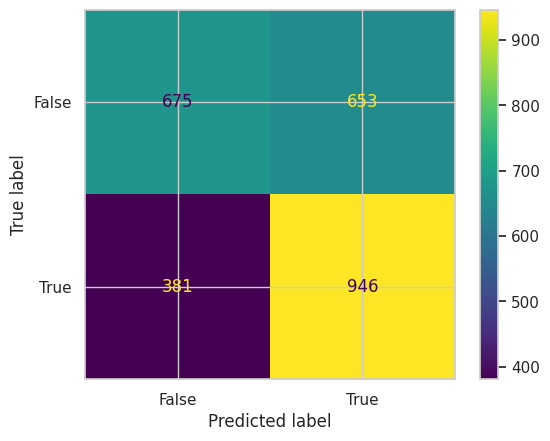

In [100]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred_LR)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

In [101]:
Specificity = metrics.recall_score(y_test, y_pred_LR, pos_label=0)
Accuracy = metrics.accuracy_score(y_test, y_pred_LR)
Precision = metrics.precision_score(y_test, y_pred_LR)
Sensitivity_recall = metrics.recall_score(y_test, y_pred_LR)
F1_score = metrics.f1_score(y_test, y_pred_LR)
print({"Accuracy":Accuracy})
print({"Precision":Precision,})
print({"Sensitivity_recall":Sensitivity_recall,})
print({"Specificity":Specificity,})
print({"F1_score":F1_score})

{'Accuracy': 0.6105461393596987}
{'Precision': 0.5916197623514696}
{'Sensitivity_recall': 0.7128862094951017}
{'Specificity': 0.5082831325301205}
{'F1_score': 0.6466165413533834}


In [102]:
#Applying Extra Trees Classifier

In [103]:
ETC = ExtraTreesClassifier()
ETC.fit(X_train, y_train)

y_pred_ETC = ETC.predict(X_test)

cl_rep_ETC = classification_report(y_test,y_pred_ETC)
print(cl_rep_ETC)

              precision    recall  f1-score   support

           0       0.67      0.73      0.70      1328
           1       0.71      0.64      0.67      1327

    accuracy                           0.69      2655
   macro avg       0.69      0.69      0.69      2655
weighted avg       0.69      0.69      0.69      2655



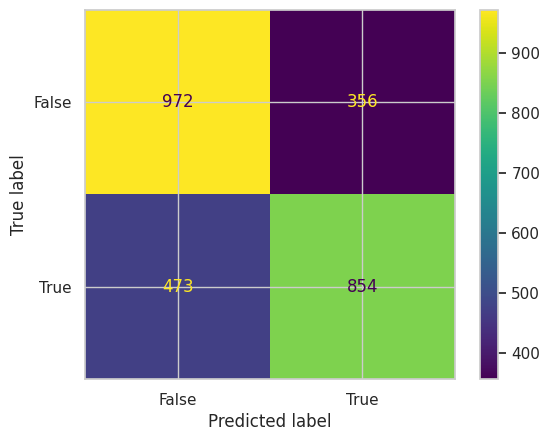

In [104]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred_ETC)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

In [105]:
Specificity = metrics.recall_score(y_test, y_pred_ETC, pos_label=0)
Accuracy = metrics.accuracy_score(y_test, y_pred_ETC)
Precision = metrics.precision_score(y_test, y_pred_ETC)
Sensitivity_recall = metrics.recall_score(y_test, y_pred_ETC)
F1_score = metrics.f1_score(y_test, y_pred_ETC)
print({"Accuracy":Accuracy})
print({"Precision":Precision,})
print({"Sensitivity_recall":Sensitivity_recall,})
print({"Specificity":Specificity,})
print({"F1_score":F1_score})

{'Accuracy': 0.6877589453860641}
{'Precision': 0.7057851239669422}
{'Sensitivity_recall': 0.6435568952524491}
{'Specificity': 0.7319277108433735}
{'F1_score': 0.6732361056365787}


In [106]:
#Applying Decision Tree Classifier

In [107]:
DTC = DecisionTreeClassifier()
DTC.fit(X_train, y_train)

y_pred_DTC = DTC.predict(X_test)

cl_rep_DTC = classification_report(y_test,y_pred_DTC)
print(cl_rep_DTC)

              precision    recall  f1-score   support

           0       0.63      0.62      0.63      1328
           1       0.63      0.63      0.63      1327

    accuracy                           0.63      2655
   macro avg       0.63      0.63      0.63      2655
weighted avg       0.63      0.63      0.63      2655



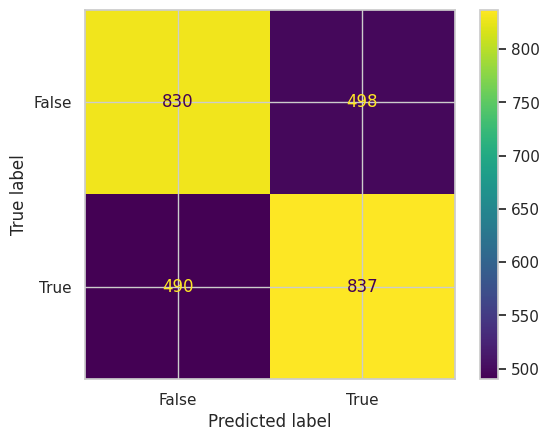

In [108]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred_DTC)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

In [109]:
Specificity = metrics.recall_score(y_test, y_pred_DTC, pos_label=0)
Accuracy = metrics.accuracy_score(y_test, y_pred_DTC)
Precision = metrics.precision_score(y_test, y_pred_DTC)
Sensitivity_recall = metrics.recall_score(y_test, y_pred_DTC)
F1_score = metrics.f1_score(y_test, y_pred_DTC)
print({"Accuracy":Accuracy})
print({"Precision":Precision,})
print({"Sensitivity_recall":Sensitivity_recall,})
print({"Specificity":Specificity,})
print({"F1_score":F1_score})

{'Accuracy': 0.6278719397363465}
{'Precision': 0.6269662921348315}
{'Sensitivity_recall': 0.6307460437076111}
{'Specificity': 0.625}
{'F1_score': 0.6288504883546205}


In [110]:
# applying Standard Scalar for normalization

In [111]:
X = df_test_under.drop('IsDefaulter',axis='columns')
y = df_test_under['IsDefaulter']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15, stratify=y)

In [112]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)
X_train.shape

(10617, 23)

In [113]:
# Number of classes in training Data
y_train.value_counts()

,count
IsDefaulter,
1,5309
0,5308


In [114]:
#Applying Logistic Regression

In [115]:
LR = LogisticRegression()
LR.fit(X_train, y_train)

y_pred_LR = LR.predict(X_test)

cl_rep_LR = classification_report(y_test,y_pred_LR)
print(cl_rep_LR)

              precision    recall  f1-score   support

           0       0.65      0.68      0.66      1328
           1       0.66      0.64      0.65      1327

    accuracy                           0.66      2655
   macro avg       0.66      0.66      0.66      2655
weighted avg       0.66      0.66      0.66      2655



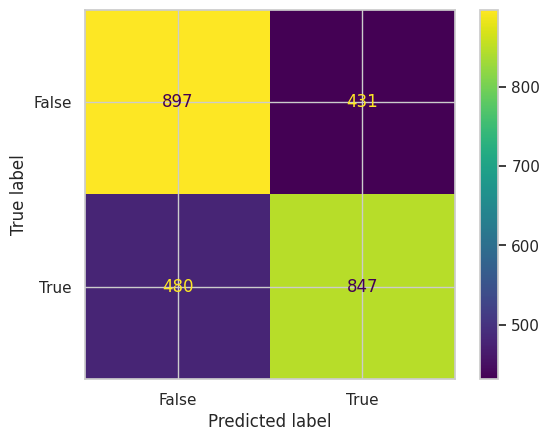

In [116]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred_LR)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

In [117]:
Specificity = metrics.recall_score(y_test, y_pred_LR, pos_label=0)
Accuracy = metrics.accuracy_score(y_test, y_pred_LR)
Precision = metrics.precision_score(y_test, y_pred_LR)
Sensitivity_recall = metrics.recall_score(y_test, y_pred_LR)
F1_score = metrics.f1_score(y_test, y_pred_LR)
print({"Accuracy":Accuracy})
print({"Precision":Precision,})
print({"Sensitivity_recall":Sensitivity_recall,})
print({"Specificity":Specificity,})
print({"F1_score":F1_score})

{'Accuracy': 0.6568738229755179}
{'Precision': 0.662754303599374}
{'Sensitivity_recall': 0.6382818387339865}
{'Specificity': 0.6754518072289156}
{'F1_score': 0.6502879078694818}


In [118]:
#Applying Extra Trees Classifier

In [119]:
ETC = ExtraTreesClassifier()
ETC.fit(X_train, y_train)

y_pred_ETC = ETC.predict(X_test)

cl_rep_ETC = classification_report(y_test,y_pred_ETC)
print(cl_rep_ETC)

              precision    recall  f1-score   support

           0       0.67      0.78      0.72      1328
           1       0.74      0.62      0.67      1327

    accuracy                           0.70      2655
   macro avg       0.70      0.70      0.70      2655
weighted avg       0.70      0.70      0.70      2655



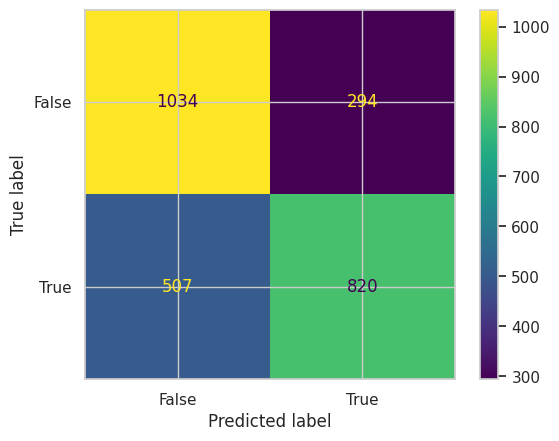

In [120]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred_ETC)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

In [121]:
Specificity = metrics.recall_score(y_test, y_pred_ETC, pos_label=0)
Accuracy = metrics.accuracy_score(y_test, y_pred_ETC)
Precision = metrics.precision_score(y_test, y_pred_ETC)
Sensitivity_recall = metrics.recall_score(y_test, y_pred_ETC)
F1_score = metrics.f1_score(y_test, y_pred_ETC)
print({"Accuracy":Accuracy})
print({"Precision":Precision,})
print({"Sensitivity_recall":Sensitivity_recall,})
print({"Specificity":Specificity,})
print({"F1_score":F1_score})

{'Accuracy': 0.6983050847457627}
{'Precision': 0.7360861759425493}
{'Sensitivity_recall': 0.6179351921627732}
{'Specificity': 0.7786144578313253}
{'F1_score': 0.6718557968045883}


In [122]:
#Applying Decision Tree Classifier

In [123]:
DTC = DecisionTreeClassifier()
DTC.fit(X_train, y_train)

y_pred_DTC = DTC.predict(X_test)

cl_rep_DTC = classification_report(y_test,y_pred_DTC)
print(cl_rep_DTC)

              precision    recall  f1-score   support

           0       0.60      0.66      0.63      1328
           1       0.62      0.56      0.59      1327

    accuracy                           0.61      2655
   macro avg       0.61      0.61      0.61      2655
weighted avg       0.61      0.61      0.61      2655



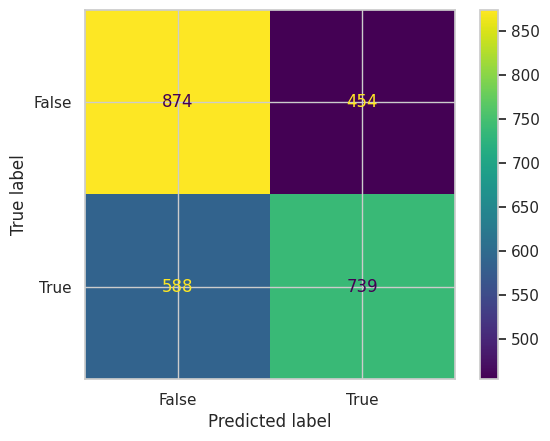

In [124]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred_DTC)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

In [125]:
Specificity = metrics.recall_score(y_test, y_pred_DTC, pos_label=0)
Accuracy = metrics.accuracy_score(y_test, y_pred_DTC)
Precision = metrics.precision_score(y_test, y_pred_DTC)
Sensitivity_recall = metrics.recall_score(y_test, y_pred_DTC)
F1_score = metrics.f1_score(y_test, y_pred_DTC)
print({"Accuracy":Accuracy})
print({"Precision":Precision,})
print({"Sensitivity_recall":Sensitivity_recall,})
print({"Specificity":Specificity,})
print({"F1_score":F1_score})

{'Accuracy': 0.607532956685499}
{'Precision': 0.6194467728415759}
{'Sensitivity_recall': 0.5568952524491334}
{'Specificity': 0.6581325301204819}
{'F1_score': 0.5865079365079365}


In [126]:
#Method2: Oversampling

In [127]:
# Oversample 1-class and concat the DataFrames of both classes
df_class_1_over = df_class_1.sample(count_class_0, replace=True)
df_test_over = pd.concat([df_class_0, df_class_1_over], axis=0)

print('Random over-sampling:')
print(df_test_over.IsDefaulter.value_counts())

Random over-sampling:
IsDefaulter
0    23364
1    23364
Name: count, dtype: int64


In [128]:
# Trying wihtout Normalization

In [129]:
X = df_test_over.drop('IsDefaulter',axis='columns')
y = df_test_over['IsDefaulter']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15, stratify=y)

In [130]:
# Number of classes in training Data
y_train.value_counts()

,count
IsDefaulter,
0,18691
1,18691


In [131]:
#Apllying Logistic Regression

In [132]:
LR = LogisticRegression()
LR.fit(X_train, y_train)

y_pred_LR = LR.predict(X_test)

cl_rep_LR = classification_report(y_test,y_pred_LR)
print(cl_rep_LR)

              precision    recall  f1-score   support

           0       0.62      0.63      0.63      4673
           1       0.63      0.62      0.62      4673

    accuracy                           0.62      9346
   macro avg       0.62      0.62      0.62      9346
weighted avg       0.62      0.62      0.62      9346



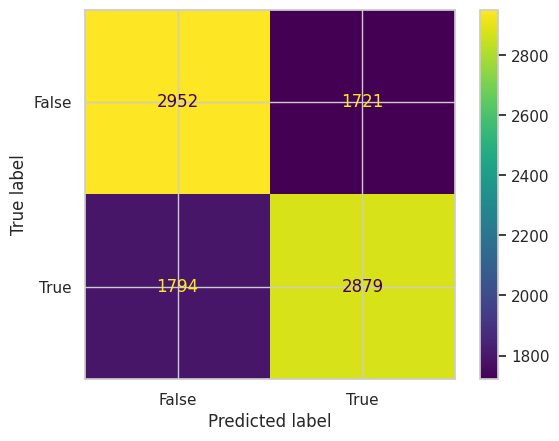

In [133]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred_LR)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

In [134]:
Specificity = metrics.recall_score(y_test, y_pred_LR, pos_label=0)
Accuracy = metrics.accuracy_score(y_test, y_pred_LR)
Precision = metrics.precision_score(y_test, y_pred_LR)
Sensitivity_recall = metrics.recall_score(y_test, y_pred_LR)
F1_score = metrics.f1_score(y_test, y_pred_LR)
print({"Accuracy":Accuracy})
print({"Precision":Precision,})
print({"Sensitivity_recall":Sensitivity_recall,})
print({"Specificity":Specificity,})
print({"F1_score":F1_score})

{'Accuracy': 0.6239032741279692}
{'Precision': 0.6258695652173913}
{'Sensitivity_recall': 0.6160924459661887}
{'Specificity': 0.6317141022897497}
{'F1_score': 0.6209425212983932}


In [135]:
#Applying Extra Tree Classifier

In [136]:
ETC = ExtraTreesClassifier()
ETC.fit(X_train, y_train)

y_pred_ETC = ETC.predict(X_test)

cl_rep_ETC = classification_report(y_test,y_pred_ETC)
print(cl_rep_ETC)

              precision    recall  f1-score   support

           0       0.96      0.93      0.95      4673
           1       0.93      0.96      0.95      4673

    accuracy                           0.95      9346
   macro avg       0.95      0.95      0.95      9346
weighted avg       0.95      0.95      0.95      9346



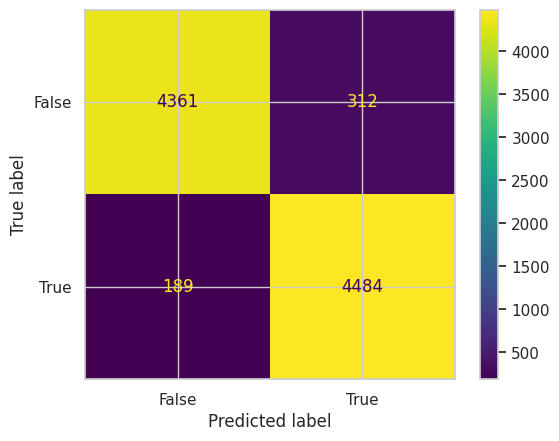

In [137]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred_ETC)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

In [138]:
Specificity = metrics.recall_score(y_test, y_pred_ETC, pos_label=0)
Accuracy = metrics.accuracy_score(y_test, y_pred_ETC)
Precision = metrics.precision_score(y_test, y_pred_ETC)
Sensitivity_recall = metrics.recall_score(y_test, y_pred_ETC)
F1_score = metrics.f1_score(y_test, y_pred_ETC)
auc_roc_score = roc_auc_score(y_test, y_pred_ETC)
print({"Accuracy":Accuracy})
print({"Precision":Precision,})
print({"Sensitivity_recall":Sensitivity_recall,})
print({"Specificity":Specificity,})
print({"F1_score":F1_score})
print({"AUC-ROC":roc_auc_score(y_test, y_pred_ETC)})

{'Accuracy': 0.9463941793280548}
{'Precision': 0.9349457881567973}
{'Sensitivity_recall': 0.9595548897924245}
{'Specificity': 0.933233468863685}
{'F1_score': 0.9470905058612313}
{'AUC-ROC': np.float64(0.9463941793280547)}


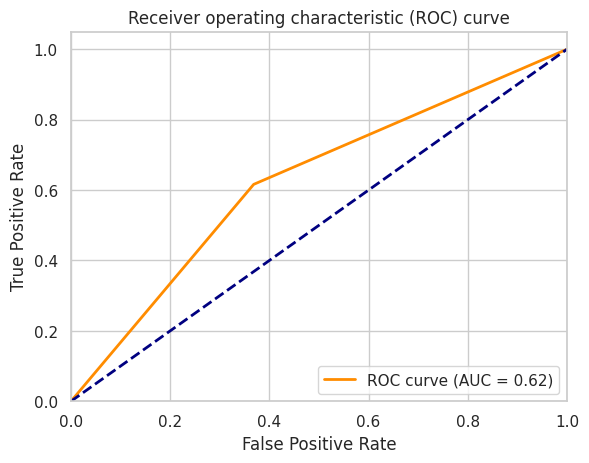

In [139]:
# y_test: true binary labels (0 or 1)
# y_pred: predicted binary labels (0 or 1)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_LR)
roc_auc = auc(fpr, tpr)

plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange', lw=lw, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic (ROC) curve')
plt.legend(loc="lower right")
plt.show()

In [140]:
#Applying Decision Tree Classifier

In [141]:
DTC = DecisionTreeClassifier()
DTC.fit(X_train, y_train)

y_pred_DTC = DTC.predict(X_test)

cl_rep_DTC = classification_report(y_test,y_pred_DTC)
print(cl_rep_DTC)

              precision    recall  f1-score   support

           0       0.95      0.82      0.88      4673
           1       0.84      0.96      0.90      4673

    accuracy                           0.89      9346
   macro avg       0.90      0.89      0.89      9346
weighted avg       0.90      0.89      0.89      9346



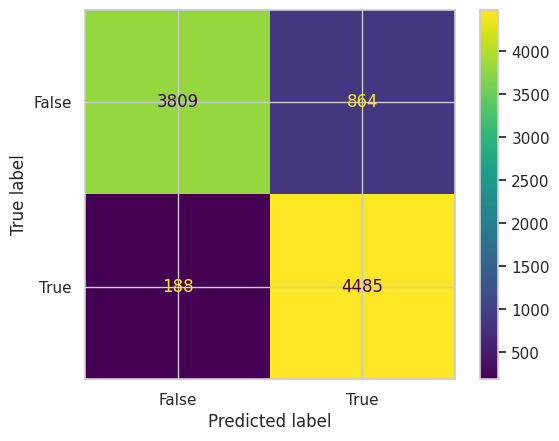

In [142]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred_DTC)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

In [143]:
Specificity = metrics.recall_score(y_test, y_pred_DTC, pos_label=0)
Accuracy = metrics.accuracy_score(y_test, y_pred_DTC)
Precision = metrics.precision_score(y_test, y_pred_DTC)
Sensitivity_recall = metrics.recall_score(y_test, y_pred_DTC)
F1_score = metrics.f1_score(y_test, y_pred_DTC)
print({"Accuracy":Accuracy})
print({"Precision":Precision,})
print({"Sensitivity_recall":Sensitivity_recall,})
print({"Specificity":Specificity,})
print({"F1_score":F1_score})

{'Accuracy': 0.8874384763535202}
{'Precision': 0.8384744812114414}
{'Sensitivity_recall': 0.9597688850845282}
{'Specificity': 0.8151080676225123}
{'F1_score': 0.8950309319497106}


In [144]:
# Applying Standard Scalar for normalization

In [145]:
X = df_test_over.drop('IsDefaulter',axis='columns')
y = df_test_over['IsDefaulter']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15, stratify=y)

In [146]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)
X_train.shape

(37382, 23)

In [147]:
# Number of classes in training Data
y_train.value_counts()

,count
IsDefaulter,
0,18691
1,18691


In [148]:
#Apllying Logistic Regression

In [149]:
LR = LogisticRegression()
LR.fit(X_train, y_train)

y_pred_LR = LR.predict(X_test)

cl_rep_LR = classification_report(y_test,y_pred_LR)
print(cl_rep_LR)

              precision    recall  f1-score   support

           0       0.66      0.71      0.68      4673
           1       0.68      0.64      0.66      4673

    accuracy                           0.67      9346
   macro avg       0.67      0.67      0.67      9346
weighted avg       0.67      0.67      0.67      9346



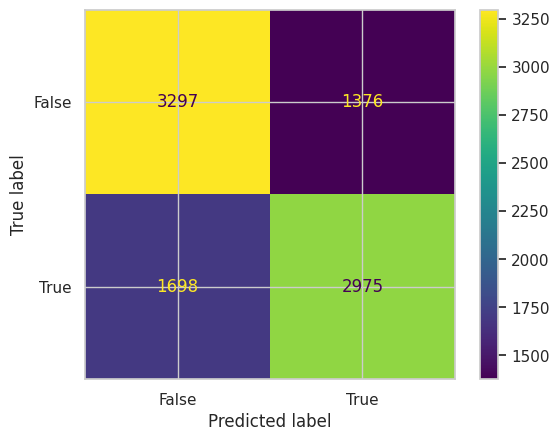

In [150]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred_LR)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

In [151]:
Specificity = metrics.recall_score(y_test, y_pred_LR, pos_label=0)
Accuracy = metrics.accuracy_score(y_test, y_pred_LR)
Precision = metrics.precision_score(y_test, y_pred_LR)
Sensitivity_recall = metrics.recall_score(y_test, y_pred_LR)
F1_score = metrics.f1_score(y_test, y_pred_LR)
print({"Accuracy":Accuracy})
print({"Precision":Precision,})
print({"Sensitivity_recall":Sensitivity_recall,})
print({"Specificity":Specificity,})
print({"F1_score":F1_score})

{'Accuracy': 0.6710892360368071}
{'Precision': 0.6837508618708343}
{'Sensitivity_recall': 0.6366359940081319}
{'Specificity': 0.7055424780654825}
{'F1_score': 0.6593528368794326}


In [152]:
#Applying Extra Tree Classifier

In [153]:
ETC = ExtraTreesClassifier()
ETC.fit(X_train, y_train)

y_pred_ETC = ETC.predict(X_test)

cl_rep_ETC = classification_report(y_test,y_pred_ETC)
print(cl_rep_ETC)

              precision    recall  f1-score   support

           0       0.86      0.95      0.90      4673
           1       0.94      0.85      0.89      4673

    accuracy                           0.90      9346
   macro avg       0.90      0.90      0.90      9346
weighted avg       0.90      0.90      0.90      9346



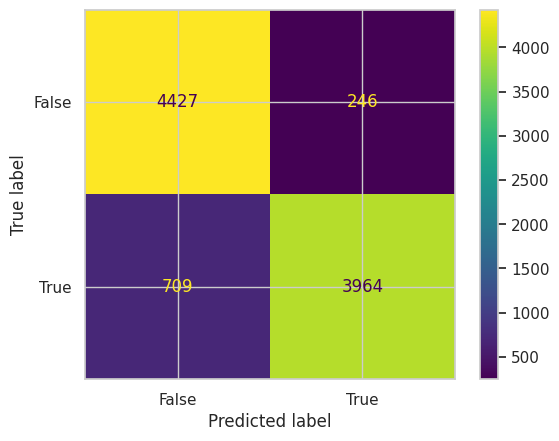

In [154]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred_ETC)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

In [155]:
Specificity = metrics.recall_score(y_test, y_pred_ETC, pos_label=0)
Accuracy = metrics.accuracy_score(y_test, y_pred_ETC)
Precision = metrics.precision_score(y_test, y_pred_ETC)
Sensitivity_recall = metrics.recall_score(y_test, y_pred_ETC)
F1_score = metrics.f1_score(y_test, y_pred_ETC)
print({"Accuracy":Accuracy})
print({"Precision":Precision,})
print({"Sensitivity_recall":Sensitivity_recall,})
print({"Specificity":Specificity,})
print({"F1_score":F1_score})

{'Accuracy': 0.8978172480205435}
{'Precision': 0.9415676959619953}
{'Sensitivity_recall': 0.8482773378985662}
{'Specificity': 0.9473571581425209}
{'F1_score': 0.8924912754699988}


In [156]:
#Applying Decision Tree Classifier

In [157]:
DTC = DecisionTreeClassifier()
DTC.fit(X_train, y_train)

y_pred_DTC = DTC.predict(X_test)

cl_rep_DTC = classification_report(y_test,y_pred_DTC)
print(cl_rep_DTC)

              precision    recall  f1-score   support

           0       0.68      0.82      0.74      4673
           1       0.78      0.62      0.69      4673

    accuracy                           0.72      9346
   macro avg       0.73      0.72      0.72      9346
weighted avg       0.73      0.72      0.72      9346



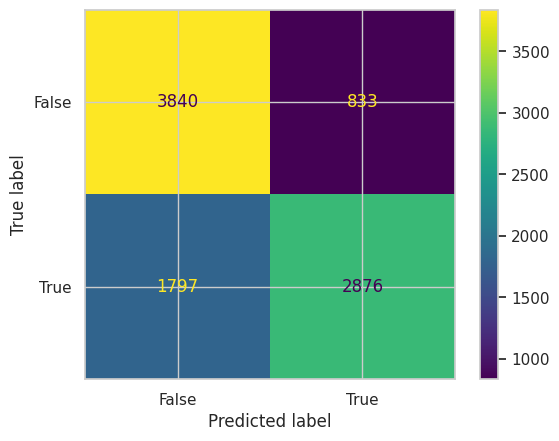

In [158]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred_DTC)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

In [159]:
Specificity = metrics.recall_score(y_test, y_pred_DTC, pos_label=0)
Accuracy = metrics.accuracy_score(y_test, y_pred_DTC)
Precision = metrics.precision_score(y_test, y_pred_DTC)
Sensitivity_recall = metrics.recall_score(y_test, y_pred_DTC)
F1_score = metrics.f1_score(y_test, y_pred_DTC)
print({"Accuracy":Accuracy})
print({"Precision":Precision,})
print({"Sensitivity_recall":Sensitivity_recall,})
print({"Specificity":Specificity,})
print({"F1_score":F1_score})

{'Accuracy': 0.7185961908838006}
{'Precision': 0.7754111620382853}
{'Sensitivity_recall': 0.615450460089878}
{'Specificity': 0.8217419216777231}
{'F1_score': 0.6862324027678358}


In [160]:
#Method3: SMOTE

In [161]:
X = df.drop('IsDefaulter',axis='columns')
y = df['IsDefaulter']

In [162]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy='auto', random_state=42, k_neighbors=5)
X_sm, y_sm = smote.fit_resample(X, y)

y_sm.value_counts()

,count
IsDefaulter,
1,23364
0,23364


In [163]:
# Trying without Normalization

In [164]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_sm, y_sm, test_size=0.2, random_state=15, stratify=y_sm)

In [165]:
# Number of classes in training Data
y_train.value_counts()

,count
IsDefaulter,
0,18691
1,18691


In [166]:
#Applying Logistic Regression

In [167]:
LR = LogisticRegression()
LR.fit(X_train, y_train)

y_pred_LR = LR.predict(X_test)

cl_rep_LR = classification_report(y_test,y_pred_LR)
print(cl_rep_LR)

              precision    recall  f1-score   support

           0       0.57      0.76      0.65      4673
           1       0.64      0.42      0.50      4673

    accuracy                           0.59      9346
   macro avg       0.60      0.59      0.58      9346
weighted avg       0.60      0.59      0.58      9346



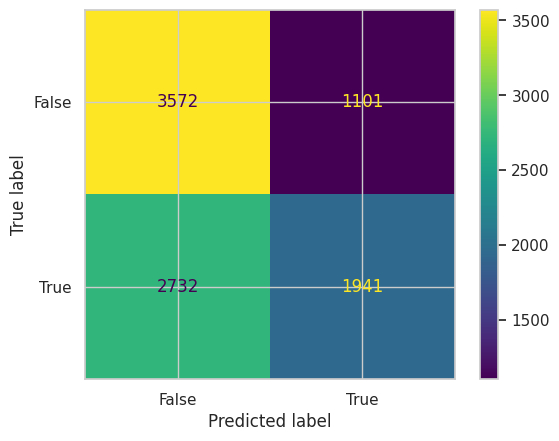

In [168]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred_LR)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

In [169]:
Specificity = metrics.recall_score(y_test, y_pred_LR, pos_label=0)
Accuracy = metrics.accuracy_score(y_test, y_pred_LR)
Precision = metrics.precision_score(y_test, y_pred_LR)
Sensitivity_recall = metrics.recall_score(y_test, y_pred_LR)
F1_score = metrics.f1_score(y_test, y_pred_LR)
print({"Accuracy":Accuracy})
print({"Precision":Precision,})
print({"Sensitivity_recall":Sensitivity_recall,})
print({"Specificity":Specificity,})
print({"F1_score":F1_score})

{'Accuracy': 0.589878022683501}
{'Precision': 0.6380670611439843}
{'Sensitivity_recall': 0.41536486197303657}
{'Specificity': 0.7643911833939653}
{'F1_score': 0.5031756318859365}


In [170]:
#Applying Extra Trees Classifier

In [171]:
ETC = ExtraTreesClassifier()
ETC.fit(X_train, y_train)

y_pred_ETC = ETC.predict(X_test)

cl_rep_ETC = classification_report(y_test,y_pred_ETC)
print(cl_rep_ETC)

              precision    recall  f1-score   support

           0       0.84      0.86      0.85      4673
           1       0.85      0.83      0.84      4673

    accuracy                           0.85      9346
   macro avg       0.85      0.85      0.85      9346
weighted avg       0.85      0.85      0.85      9346



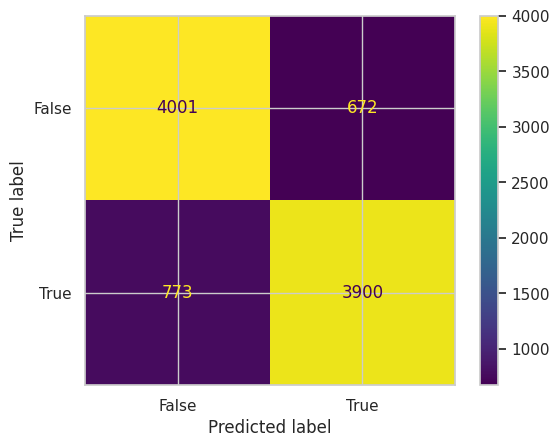

In [172]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred_ETC)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

In [173]:
Specificity = metrics.recall_score(y_test, y_pred_ETC, pos_label=0)
Accuracy = metrics.accuracy_score(y_test, y_pred_ETC)
Precision = metrics.precision_score(y_test, y_pred_ETC)
Sensitivity_recall = metrics.recall_score(y_test, y_pred_ETC)
F1_score = metrics.f1_score(y_test, y_pred_ETC)
print({"Accuracy":Accuracy})
print({"Precision":Precision,})
print({"Sensitivity_recall":Sensitivity_recall,})
print({"Specificity":Specificity,})
print({"F1_score":F1_score})

{'Accuracy': 0.845388401455168}
{'Precision': 0.8530183727034121}
{'Sensitivity_recall': 0.8345816392039375}
{'Specificity': 0.8561951637063985}
{'F1_score': 0.8436992969172525}


In [174]:
#Applying Decision Trees Classifier

In [175]:
DTC = DecisionTreeClassifier()
DTC.fit(X_train, y_train)

y_pred_DTC = DTC.predict(X_test)

cl_rep_DTC = classification_report(y_test,y_pred_DTC)
print(cl_rep_DTC)

              precision    recall  f1-score   support

           0       0.78      0.75      0.76      4673
           1       0.76      0.78      0.77      4673

    accuracy                           0.77      9346
   macro avg       0.77      0.77      0.77      9346
weighted avg       0.77      0.77      0.77      9346



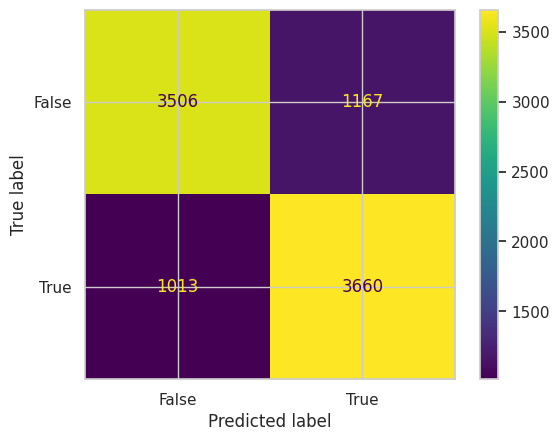

In [176]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred_DTC)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

In [177]:
Specificity = metrics.recall_score(y_test, y_pred_DTC, pos_label=0)
Accuracy = metrics.accuracy_score(y_test, y_pred_DTC)
Precision = metrics.precision_score(y_test, y_pred_DTC)
Sensitivity_recall = metrics.recall_score(y_test, y_pred_DTC)
F1_score = metrics.f1_score(y_test, y_pred_DTC)
print({"Accuracy":Accuracy})
print({"Precision":Precision,})
print({"Sensitivity_recall":Sensitivity_recall,})
print({"Specificity":Specificity,})
print({"F1_score":F1_score})

{'Accuracy': 0.7667451316071047}
{'Precision': 0.7582349285270354}
{'Sensitivity_recall': 0.7832227690990798}
{'Specificity': 0.7502674941151295}
{'F1_score': 0.7705263157894737}


In [178]:
#Applying Standard Scalar for normalization

In [179]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_sm, y_sm, test_size=0.2, random_state=15, stratify=y_sm)

In [180]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)
X_train.shape

(37382, 23)

In [181]:
# Number of classes in training Data
y_train.value_counts()

,count
IsDefaulter,
0,18691
1,18691


In [182]:
#Applying Logistic Regression

In [183]:
LR = LogisticRegression()
LR.fit(X_train, y_train)

y_pred_LR = LR.predict(X_test)

cl_rep_LR = classification_report(y_test,y_pred_LR)
print(cl_rep_LR)

              precision    recall  f1-score   support

           0       0.73      0.72      0.72      4673
           1       0.72      0.73      0.73      4673

    accuracy                           0.72      9346
   macro avg       0.72      0.72      0.72      9346
weighted avg       0.72      0.72      0.72      9346



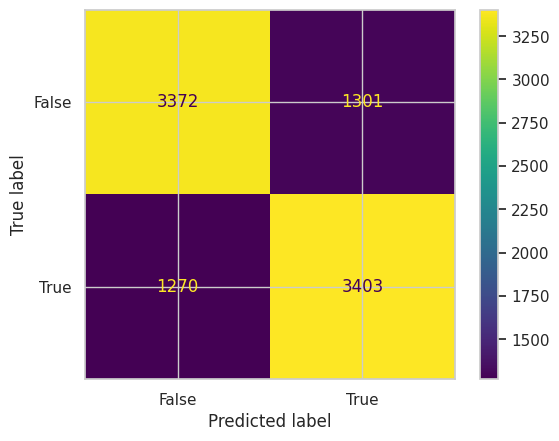

In [184]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred_LR)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

In [185]:
Specificity = metrics.recall_score(y_test, y_pred_LR, pos_label=0)
Accuracy = metrics.accuracy_score(y_test, y_pred_LR)
Precision = metrics.precision_score(y_test, y_pred_LR)
Sensitivity_recall = metrics.recall_score(y_test, y_pred_LR)
F1_score = metrics.f1_score(y_test, y_pred_LR)
print({"Accuracy":Accuracy})
print({"Precision":Precision,})
print({"Sensitivity_recall":Sensitivity_recall,})
print({"Specificity":Specificity,})
print({"F1_score":F1_score})

{'Accuracy': 0.724909052000856}
{'Precision': 0.7234268707482994}
{'Sensitivity_recall': 0.7282259790284614}
{'Specificity': 0.7215921249732505}
{'F1_score': 0.7258184920550282}


In [186]:
#Applying Extra Trees Classifier

In [187]:
ETC = ExtraTreesClassifier()
ETC.fit(X_train, y_train)

y_pred_ETC = ETC.predict(X_test)

cl_rep_ETC = classification_report(y_test,y_pred_ETC)
print(cl_rep_ETC)

              precision    recall  f1-score   support

           0       0.82      0.86      0.84      4673
           1       0.85      0.81      0.83      4673

    accuracy                           0.84      9346
   macro avg       0.84      0.84      0.84      9346
weighted avg       0.84      0.84      0.84      9346



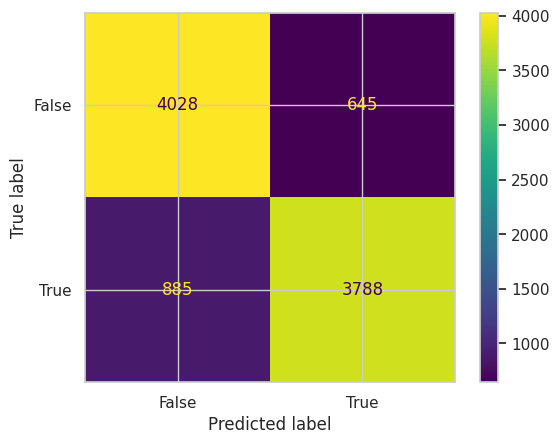

In [188]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred_ETC)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

In [189]:
Specificity = metrics.recall_score(y_test, y_pred_ETC, pos_label=0)
Accuracy = metrics.accuracy_score(y_test, y_pred_ETC)
Precision = metrics.precision_score(y_test, y_pred_ETC)
Sensitivity_recall = metrics.recall_score(y_test, y_pred_ETC)
F1_score = metrics.f1_score(y_test, y_pred_ETC)
print({"Accuracy":Accuracy})
print({"Precision":Precision,})
print({"Sensitivity_recall":Sensitivity_recall,})
print({"Specificity":Specificity,})
print({"F1_score":F1_score})

{'Accuracy': 0.8362936015407662}
{'Precision': 0.8545003383713061}
{'Sensitivity_recall': 0.8106141664883373}
{'Specificity': 0.8619730365931949}
{'F1_score': 0.8319789150010982}


In [190]:
#Applying Decision Trees Classifier

In [191]:
DTC = DecisionTreeClassifier()
DTC.fit(X_train, y_train)

y_pred_DTC = DTC.predict(X_test)

cl_rep_DTC = classification_report(y_test,y_pred_DTC)
print(cl_rep_DTC)

              precision    recall  f1-score   support

           0       0.72      0.72      0.72      4673
           1       0.72      0.72      0.72      4673

    accuracy                           0.72      9346
   macro avg       0.72      0.72      0.72      9346
weighted avg       0.72      0.72      0.72      9346



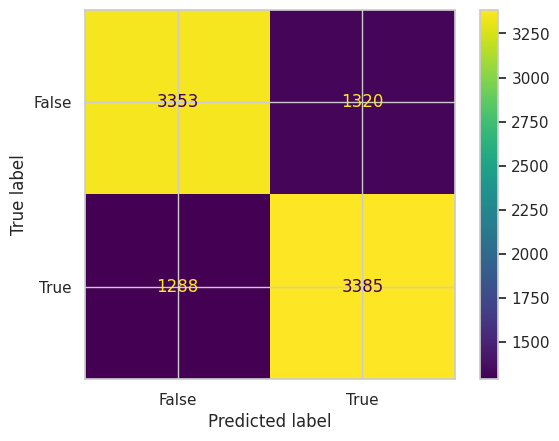

In [192]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred_DTC)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

In [193]:
Specificity = metrics.recall_score(y_test, y_pred_DTC, pos_label=0)
Accuracy = metrics.accuracy_score(y_test, y_pred_DTC)
Precision = metrics.precision_score(y_test, y_pred_DTC)
Sensitivity_recall = metrics.recall_score(y_test, y_pred_DTC)
F1_score = metrics.f1_score(y_test, y_pred_DTC)
print({"Accuracy":Accuracy})
print({"Precision":Precision,})
print({"Sensitivity_recall":Sensitivity_recall,})
print({"Specificity":Specificity,})
print({"F1_score":F1_score})

{'Accuracy': 0.7209501390969398}
{'Precision': 0.7194473963868225}
{'Sensitivity_recall': 0.7243740637705971}
{'Specificity': 0.7175262144232827}
{'F1_score': 0.7219023245894647}


In [194]:
#Method4: Use of Ensemble

In [195]:
X = df.drop('IsDefaulter',axis='columns')
y = df['IsDefaulter']

In [196]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [197]:
y_train.value_counts()

,count
IsDefaulter,
0,18691
1,5309


In [198]:
df3 = X_train.copy()
df3['IsDefaulter'] = y_train

In [199]:
df3.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,IsDefaulter
22788,160000,2,2,2,33,2,2,3,2,0,...,164310,162681,163005,15000,0,0,6100,12300,6100,0
29006,150000,2,1,2,34,1,-1,-1,-2,-2,...,0,0,0,53,0,0,0,0,0,0
16950,10000,1,2,1,50,1,2,0,0,0,...,8067,8227,8400,2,1281,1134,294,305,1000,0
22280,220000,2,1,2,29,0,0,0,0,0,...,218513,131660,134346,9100,9000,7887,4800,4900,6000,1
11346,310000,2,1,2,32,1,-2,-1,0,0,...,326,-235,-235,0,326,0,0,0,1200,0


In [200]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24000 entries, 22788 to 27126
Data columns (total 24 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   LIMIT_BAL    24000 non-null  int64
 1   SEX          24000 non-null  int64
 2   EDUCATION    24000 non-null  int64
 3   MARRIAGE     24000 non-null  int64
 4   AGE          24000 non-null  int64
 5   PAY_0        24000 non-null  int64
 6   PAY_2        24000 non-null  int64
 7   PAY_3        24000 non-null  int64
 8   PAY_4        24000 non-null  int64
 9   PAY_5        24000 non-null  int64
 10  PAY_6        24000 non-null  int64
 11  BILL_AMT1    24000 non-null  int64
 12  BILL_AMT2    24000 non-null  int64
 13  BILL_AMT3    24000 non-null  int64
 14  BILL_AMT4    24000 non-null  int64
 15  BILL_AMT5    24000 non-null  int64
 16  BILL_AMT6    24000 non-null  int64
 17  PAY_AMT1     24000 non-null  int64
 18  PAY_AMT2     24000 non-null  int64
 19  PAY_AMT3     24000 non-null  int64
 20  PAY_AMT

In [201]:
df3_class0 = df3[df3.IsDefaulter==0]
df3_class1 = df3[df3.IsDefaulter==1]

In [202]:
def get_train_batch(df_majority, df_minority, start, end):
    df_train = pd.concat([df_majority[start:end], df_minority[start:end]], axis=0)
    X_train = df_train.drop('IsDefaulter', axis='columns')
    y_train = df_train.IsDefaulter
    return X_train, y_train

In [203]:
X_train, y_train = get_train_batch(df3_class0, df3_class1, 0, 1482)

LR1 = LogisticRegression()
LR1.fit(X_train, y_train)
y_pred1_LR = LR1.predict(X_test)

In [204]:
X_train, y_train = get_train_batch(df3_class0, df3_class1, 1483, 2964)

LR2 = LogisticRegression()
LR2.fit(X_train, y_train)
y_pred2_LR = LR2.predict(X_test)

In [205]:
X_train, y_train = get_train_batch(df3_class0, df3_class1, 2965, 4446)

LR3 = LogisticRegression()
LR3.fit(X_train, y_train)
y_pred3_LR = LR3.predict(X_test)

In [206]:
len(y_pred1_LR)

6000

In [207]:
y_pred_LR = y_pred1_LR.copy()
for i in range(len(y_pred1_LR)):
    n_ones = y_pred1_LR[i] + y_pred2_LR[i] + y_pred3_LR[i]
    if n_ones>1:
        y_pred_LR[i] = 1
    else:
        y_pred_LR[i] = 0

In [208]:
cl_rep_LR = classification_report(y_test, y_pred_LR)
print(cl_rep_LR)

              precision    recall  f1-score   support

           0       0.85      0.53      0.65      4673
           1       0.29      0.68      0.41      1327

    accuracy                           0.56      6000
   macro avg       0.57      0.61      0.53      6000
weighted avg       0.73      0.56      0.60      6000



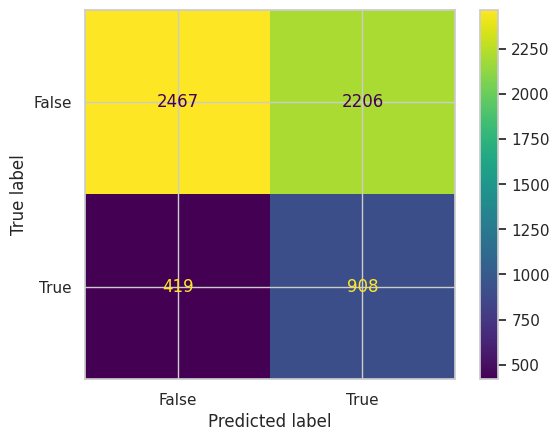

In [209]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred_LR)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

In [210]:
Specificity = metrics.recall_score(y_test, y_pred_LR, pos_label=0)
Accuracy = metrics.accuracy_score(y_test, y_pred_LR)
Precision = metrics.precision_score(y_test, y_pred_LR)
Sensitivity_recall = metrics.recall_score(y_test, y_pred_LR)
F1_score = metrics.f1_score(y_test, y_pred_LR)
print({"Accuracy":Accuracy})
print({"Precision":Precision,})
print({"Sensitivity_recall":Sensitivity_recall,})
print({"Specificity":Specificity,})
print({"F1_score":F1_score})

{'Accuracy': 0.5625}
{'Precision': 0.2915863840719332}
{'Sensitivity_recall': 0.6842501883948756}
{'Specificity': 0.5279263856195163}
{'F1_score': 0.40891691060571944}


In [211]:
X_train, y_train = get_train_batch(df3_class0, df3_class1, 0, 1482)

ETC1 = ExtraTreesClassifier()
ETC1.fit(X_train, y_train)
y_pred1_ETC = ETC1.predict(X_test)

In [212]:
X_train, y_train = get_train_batch(df3_class0, df3_class1, 1483, 2964)

ETC2 = ExtraTreesClassifier()
ETC2.fit(X_train, y_train)
y_pred2_ETC = ETC2.predict(X_test)

In [213]:
X_train, y_train = get_train_batch(df3_class0, df3_class1, 2965, 4446)

ETC3 = ExtraTreesClassifier()
ETC3.fit(X_train, y_train)
y_pred3_ETC = ETC3.predict(X_test)

In [214]:
len(y_pred1_ETC)

6000

In [215]:
y_pred_ETC = y_pred1_ETC.copy()
for i in range(len(y_pred1_ETC)):
    n_ones = y_pred1_ETC[i] + y_pred2_ETC[i] + y_pred3_ETC[i]
    if n_ones>1:
        y_pred_ETC[i] = 1
    else:
        y_pred_ETC[i] = 0

In [216]:
cl_rep_ETC = classification_report(y_test, y_pred_ETC)
print(cl_rep_ETC)

              precision    recall  f1-score   support

           0       0.88      0.77      0.82      4673
           1       0.44      0.63      0.52      1327

    accuracy                           0.74      6000
   macro avg       0.66      0.70      0.67      6000
weighted avg       0.78      0.74      0.76      6000



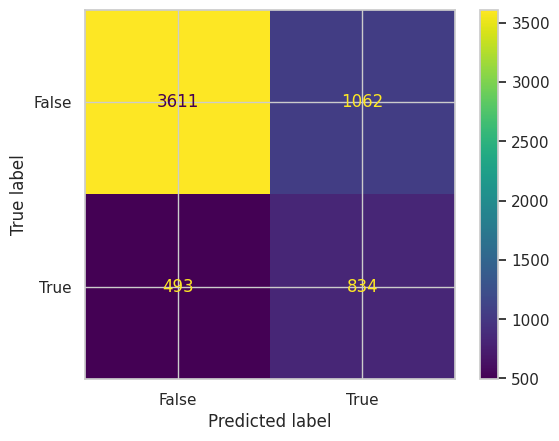

In [217]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred_ETC)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

In [218]:
Specificity = metrics.recall_score(y_test, y_pred_ETC, pos_label=0)
Accuracy = metrics.accuracy_score(y_test, y_pred_ETC)
Precision = metrics.precision_score(y_test, y_pred_ETC)
Sensitivity_recall = metrics.recall_score(y_test, y_pred_ETC)
F1_score = metrics.f1_score(y_test, y_pred_ETC)
print({"Accuracy":Accuracy})
print({"Precision":Precision,})
print({"Sensitivity_recall":Sensitivity_recall,})
print({"Specificity":Specificity,})
print({"F1_score":F1_score})

{'Accuracy': 0.7408333333333333}
{'Precision': 0.439873417721519}
{'Sensitivity_recall': 0.6284853051996986}
{'Specificity': 0.7727369997860047}
{'F1_score': 0.5175302513186473}


In [219]:
X_train, y_train = get_train_batch(df3_class0, df3_class1, 0, 1482)

DTC1 = DecisionTreeClassifier()
DTC1.fit(X_train, y_train)
y_pred1_DTC = DTC1.predict(X_test)

In [220]:
X_train, y_train = get_train_batch(df3_class0, df3_class1, 1483, 2964)

DTC2 = DecisionTreeClassifier()
DTC2.fit(X_train, y_train)
y_pred2_DTC = DTC2.predict(X_test)

In [221]:
X_train, y_train = get_train_batch(df3_class0, df3_class1, 2965, 4446)

DTC3 = DecisionTreeClassifier()
DTC3.fit(X_train, y_train)
y_pred3_DTC = DTC3.predict(X_test)

In [222]:
len(y_pred1_DTC)

6000

In [223]:
y_pred_DTC = y_pred1_DTC.copy()
for i in range(len(y_pred1_DTC)):
    n_ones = y_pred1_DTC[i] + y_pred2_DTC[i] + y_pred3_DTC[i]
    if n_ones>1:
        y_pred_DTC[i] = 1
    else:
        y_pred_DTC[i] = 0

In [224]:
cl_rep_DTC = classification_report(y_test, y_pred_DTC)
print(cl_rep_DTC)

              precision    recall  f1-score   support

           0       0.86      0.65      0.74      4673
           1       0.33      0.61      0.43      1327

    accuracy                           0.64      6000
   macro avg       0.60      0.63      0.59      6000
weighted avg       0.74      0.64      0.67      6000



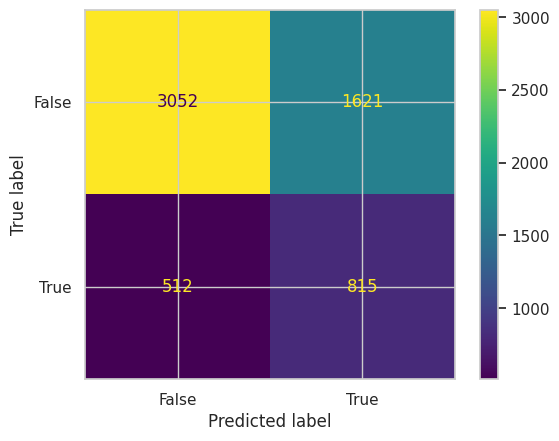

In [225]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred_DTC)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

In [226]:
Specificity = metrics.recall_score(y_test, y_pred_DTC, pos_label=0)
Accuracy = metrics.accuracy_score(y_test, y_pred_DTC)
Precision = metrics.precision_score(y_test, y_pred_DTC)
Sensitivity_recall = metrics.recall_score(y_test, y_pred_DTC)
F1_score = metrics.f1_score(y_test, y_pred_DTC)
print({"Accuracy":Accuracy})
print({"Precision":Precision,})
print({"Sensitivity_recall":Sensitivity_recall,})
print({"Specificity":Specificity,})
print({"F1_score":F1_score})

{'Accuracy': 0.6445}
{'Precision': 0.3345648604269294}
{'Sensitivity_recall': 0.6141672946495855}
{'Specificity': 0.653113631500107}
{'F1_score': 0.43316502790326866}


In [227]:
# Ensemble with UnderSampling

In [228]:
# Class count
count_class_0, count_class_1 = df.IsDefaulter.value_counts()

# Divide by class
df_class_0 = df[df['IsDefaulter'] == 0]
df_class_1 = df[df['IsDefaulter'] == 1]

In [229]:
# Undersample 0-class and concat the DataFrames of both class
df_class_0_under = df_class_0.sample(count_class_1)
df_test_under = pd.concat([df_class_0_under, df_class_1], axis=0)

print('Random under-sampling:')
print(df_test_under.IsDefaulter.value_counts())

Random under-sampling:
IsDefaulter
0    6636
1    6636
Name: count, dtype: int64


In [230]:
X = df_test_under.drop('IsDefaulter',axis='columns')
y = df_test_under['IsDefaulter']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15, stratify=y)

In [231]:
df_test_under.IsDefaulter.value_counts()

,count
IsDefaulter,
0,6636
1,6636


In [232]:
y_train.value_counts()

,count
IsDefaulter,
1,5309
0,5308


In [233]:
df3 = X_train.copy()
df3['IsDefaulter'] = y_train

In [234]:
df3.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,IsDefaulter
10139,80000,2,2,2,27,0,0,0,-1,0,...,20202,20077,20247,2000,5056,20202,726,891,10000,1
24337,310000,1,1,1,33,1,2,0,0,0,...,70995,45838,36252,40,3959,2807,2000,3000,2000,0
21335,50000,1,2,1,53,0,0,0,0,0,...,49099,19739,19905,1998,2374,1130,523,537,633,0
18914,120000,2,2,1,28,1,2,0,0,0,...,60990,61960,65233,0,3000,3000,3000,5000,0,1
3609,310000,1,1,2,32,0,0,0,0,0,...,59169,12056,10032,69220,3095,5000,2000,10058,23219,0


In [235]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10617 entries, 10139 to 28274
Data columns (total 24 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   LIMIT_BAL    10617 non-null  int64
 1   SEX          10617 non-null  int64
 2   EDUCATION    10617 non-null  int64
 3   MARRIAGE     10617 non-null  int64
 4   AGE          10617 non-null  int64
 5   PAY_0        10617 non-null  int64
 6   PAY_2        10617 non-null  int64
 7   PAY_3        10617 non-null  int64
 8   PAY_4        10617 non-null  int64
 9   PAY_5        10617 non-null  int64
 10  PAY_6        10617 non-null  int64
 11  BILL_AMT1    10617 non-null  int64
 12  BILL_AMT2    10617 non-null  int64
 13  BILL_AMT3    10617 non-null  int64
 14  BILL_AMT4    10617 non-null  int64
 15  BILL_AMT5    10617 non-null  int64
 16  BILL_AMT6    10617 non-null  int64
 17  PAY_AMT1     10617 non-null  int64
 18  PAY_AMT2     10617 non-null  int64
 19  PAY_AMT3     10617 non-null  int64
 20  PAY_AMT

In [236]:
df3_class0 = df3[df3.IsDefaulter==0]
df3_class1 = df3[df3.IsDefaulter==1]

In [237]:
def get_train_batch(df_majority, df_minority, start, end):
    df_train = pd.concat([df_majority[start:end], df_minority[start:end]], axis=0)
    X_train = df_train.drop('IsDefaulter', axis='columns')
    y_train = df_train.IsDefaulter
    return X_train, y_train

In [238]:
X_train, y_train = get_train_batch(df3_class0, df3_class1, 0, 1482)

LR1 = LogisticRegression()
LR1.fit(X_train, y_train)
y_pred1_LR = LR1.predict(X_test)

In [239]:
X_train, y_train = get_train_batch(df3_class0, df3_class1, 1483, 2964)

LR2 = LogisticRegression()
LR2.fit(X_train, y_train)
y_pred2_LR = LR2.predict(X_test)

In [240]:
X_train, y_train = get_train_batch(df3_class0, df3_class1, 2965, 4446)

LR3 = LogisticRegression()
LR3.fit(X_train, y_train)
y_pred3_LR = LR3.predict(X_test)

In [241]:
len(y_pred1_LR)

2655

In [242]:
y_pred_LR = y_pred1_LR.copy()
for i in range(len(y_pred1_LR)):
    n_ones = y_pred1_LR[i] + y_pred2_LR[i] + y_pred3_LR[i]
    if n_ones>1:
        y_pred_LR[i] = 1
    else:
        y_pred_LR[i] = 0

In [243]:
cl_rep_LR = classification_report(y_test, y_pred_LR)
print(cl_rep_LR)

              precision    recall  f1-score   support

           0       0.61      0.61      0.61      1328
           1       0.61      0.60      0.60      1327

    accuracy                           0.61      2655
   macro avg       0.61      0.61      0.61      2655
weighted avg       0.61      0.61      0.61      2655



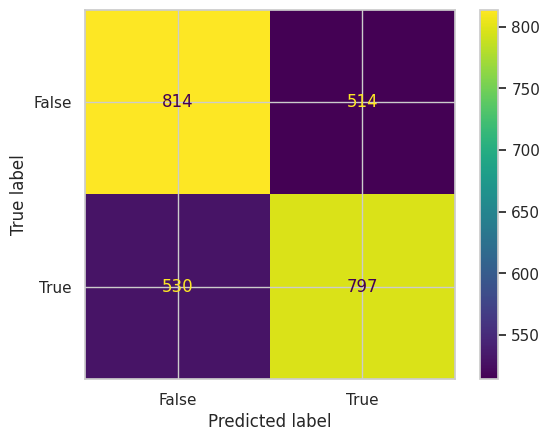

In [244]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred_LR)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

In [245]:
Specificity = metrics.recall_score(y_test, y_pred_LR, pos_label=0)
Accuracy = metrics.accuracy_score(y_test, y_pred_LR)
Precision = metrics.precision_score(y_test, y_pred_LR)
Sensitivity_recall = metrics.recall_score(y_test, y_pred_LR)
F1_score = metrics.f1_score(y_test, y_pred_LR)
print({"Accuracy":Accuracy})
print({"Precision":Precision,})
print({"Sensitivity_recall":Sensitivity_recall,})
print({"Specificity":Specificity,})
print({"F1_score":F1_score})

{'Accuracy': 0.6067796610169491}
{'Precision': 0.6079328756674295}
{'Sensitivity_recall': 0.60060286360211}
{'Specificity': 0.6129518072289156}
{'F1_score': 0.604245640636846}


In [246]:
X_train, y_train = get_train_batch(df3_class0, df3_class1, 0, 1482)

ETC1 = ExtraTreesClassifier()
ETC1.fit(X_train, y_train)
y_pred1_ETC = ETC1.predict(X_test)

In [247]:
X_train, y_train = get_train_batch(df3_class0, df3_class1, 1483, 2964)

ETC2 = ExtraTreesClassifier()
ETC2.fit(X_train, y_train)
y_pred2_ETC = ETC2.predict(X_test)

In [248]:
X_train, y_train = get_train_batch(df3_class0, df3_class1, 2965, 4446)

ETC3 = ExtraTreesClassifier()
ETC3.fit(X_train, y_train)
y_pred3_ETC = ETC3.predict(X_test)

In [249]:
len(y_pred1_ETC)

2655

In [250]:
y_pred_ETC = y_pred1_ETC.copy()
for i in range(len(y_pred1_ETC)):
    n_ones = y_pred1_ETC[i] + y_pred2_ETC[i] + y_pred3_ETC[i]
    if n_ones>1:
        y_pred_ETC[i] = 1
    else:
        y_pred_ETC[i] = 0

In [251]:
cl_rep_ETC = classification_report(y_test, y_pred_ETC)
print(cl_rep_ETC)

              precision    recall  f1-score   support

           0       0.69      0.78      0.73      1328
           1       0.75      0.64      0.69      1327

    accuracy                           0.71      2655
   macro avg       0.72      0.71      0.71      2655
weighted avg       0.72      0.71      0.71      2655



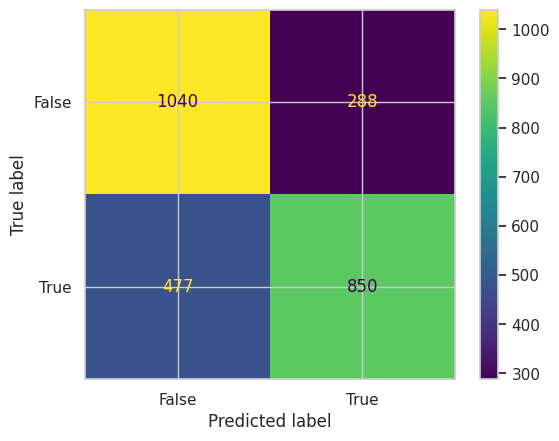

In [252]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred_ETC)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

In [253]:
Specificity = metrics.recall_score(y_test, y_pred_ETC, pos_label=0)
Accuracy = metrics.accuracy_score(y_test, y_pred_ETC)
Precision = metrics.precision_score(y_test, y_pred_ETC)
Sensitivity_recall = metrics.recall_score(y_test, y_pred_ETC)
F1_score = metrics.f1_score(y_test, y_pred_ETC)
print({"Accuracy":Accuracy})
print({"Precision":Precision,})
print({"Sensitivity_recall":Sensitivity_recall,})
print({"Specificity":Specificity,})
print({"F1_score":F1_score})

{'Accuracy': 0.711864406779661}
{'Precision': 0.7469244288224957}
{'Sensitivity_recall': 0.640542577241899}
{'Specificity': 0.7831325301204819}
{'F1_score': 0.6896551724137931}


In [254]:
X_train, y_train = get_train_batch(df3_class0, df3_class1, 0, 1482)

DTC1 = DecisionTreeClassifier()
DTC1.fit(X_train, y_train)
y_pred1_DTC = DTC1.predict(X_test)

In [255]:
X_train, y_train = get_train_batch(df3_class0, df3_class1, 1483, 2964)

DTC2 = DecisionTreeClassifier()
DTC2.fit(X_train, y_train)
y_pred2_DTC = DTC2.predict(X_test)

In [256]:
X_train, y_train = get_train_batch(df3_class0, df3_class1, 2965, 4446)

DTC3 = DecisionTreeClassifier()
DTC3.fit(X_train, y_train)
y_pred3_DTC = DTC3.predict(X_test)

In [257]:
len(y_pred1_DTC)

2655

In [258]:
y_pred_DTC = y_pred1_DTC.copy()
for i in range(len(y_pred1_DTC)):
    n_ones = y_pred1_DTC[i] + y_pred2_DTC[i] + y_pred3_DTC[i]
    if n_ones>1:
        y_pred_DTC[i] = 1
    else:
        y_pred_DTC[i] = 0

In [259]:
cl_rep_DTC = classification_report(y_test, y_pred_DTC)
print(cl_rep_DTC)

              precision    recall  f1-score   support

           0       0.65      0.64      0.65      1328
           1       0.65      0.65      0.65      1327

    accuracy                           0.65      2655
   macro avg       0.65      0.65      0.65      2655
weighted avg       0.65      0.65      0.65      2655



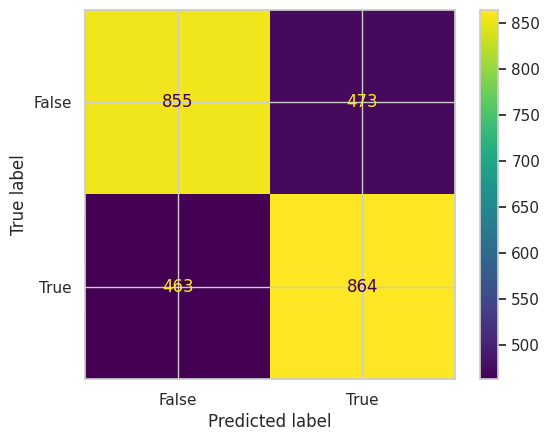

In [260]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred_DTC)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

In [261]:
Specificity = metrics.recall_score(y_test, y_pred_DTC, pos_label=0)
Accuracy = metrics.accuracy_score(y_test, y_pred_DTC)
Precision = metrics.precision_score(y_test, y_pred_DTC)
Sensitivity_recall = metrics.recall_score(y_test, y_pred_DTC)
F1_score = metrics.f1_score(y_test, y_pred_DTC)
print({"Accuracy":Accuracy})
print({"Precision":Precision,})
print({"Sensitivity_recall":Sensitivity_recall,})
print({"Specificity":Specificity,})
print({"F1_score":F1_score})

{'Accuracy': 0.6474576271186441}
{'Precision': 0.6462228870605834}
{'Sensitivity_recall': 0.6510926902788244}
{'Specificity': 0.6438253012048193}
{'F1_score': 0.6486486486486487}


In [262]:
# Ensemble with OverSampling

In [263]:
# Class count
count_class_0, count_class_1 = df.IsDefaulter.value_counts()

# Divide by class
df_class_0 = df[df['IsDefaulter'] == 0]
df_class_1 = df[df['IsDefaulter'] == 1]

In [264]:
# Oversample 1-class and concat the DataFrames of both class
df_class_1_over = df_class_1.sample(count_class_0, replace=True)
df_test_over = pd.concat([df_class_0, df_class_1_over], axis=0)

print('Random over-sampling:')
print(df_test_over.IsDefaulter.value_counts())

Random over-sampling:
IsDefaulter
0    23364
1    23364
Name: count, dtype: int64


In [265]:
X = df_test_over.drop('IsDefaulter',axis='columns')
y = df_test_over['IsDefaulter']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15, stratify=y)

In [266]:
df_test_over.IsDefaulter.value_counts()

,count
IsDefaulter,
0,23364
1,23364


In [267]:
y_train.value_counts()

,count
IsDefaulter,
0,18691
1,18691


In [268]:
df3 = X_train.copy()
df3['IsDefaulter'] = y_train

In [269]:
df3.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,IsDefaulter
7090,120000,2,2,2,29,0,0,0,0,0,...,116877,117359,117029,6000,5500,4160,4120,4250,4380,0
3433,20000,1,1,2,22,0,0,0,0,0,...,18674,15452,15882,3004,3006,3007,489,2110,2201,0
6057,230000,1,1,1,44,-1,-1,-1,-1,0,...,1630,815,815,815,815,1630,0,815,629,0
1727,60000,2,2,1,42,2,2,0,0,0,...,18919,16853,29682,0,2000,2000,1000,20000,10000,1
20013,350000,2,1,1,42,-1,2,-1,-1,-1,...,1559,1962,3683,0,27036,1559,1962,3683,3074,0


In [270]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37382 entries, 7090 to 16346
Data columns (total 24 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   LIMIT_BAL    37382 non-null  int64
 1   SEX          37382 non-null  int64
 2   EDUCATION    37382 non-null  int64
 3   MARRIAGE     37382 non-null  int64
 4   AGE          37382 non-null  int64
 5   PAY_0        37382 non-null  int64
 6   PAY_2        37382 non-null  int64
 7   PAY_3        37382 non-null  int64
 8   PAY_4        37382 non-null  int64
 9   PAY_5        37382 non-null  int64
 10  PAY_6        37382 non-null  int64
 11  BILL_AMT1    37382 non-null  int64
 12  BILL_AMT2    37382 non-null  int64
 13  BILL_AMT3    37382 non-null  int64
 14  BILL_AMT4    37382 non-null  int64
 15  BILL_AMT5    37382 non-null  int64
 16  BILL_AMT6    37382 non-null  int64
 17  PAY_AMT1     37382 non-null  int64
 18  PAY_AMT2     37382 non-null  int64
 19  PAY_AMT3     37382 non-null  int64
 20  PAY_AMT4

In [271]:
df3_class0 = df3[df3.IsDefaulter==0]
df3_class1 = df3[df3.IsDefaulter==1]

In [272]:
def get_train_batch(df_majority, df_minority, start, end):
    df_train = pd.concat([df_majority[start:end], df_minority[start:end]], axis=0)
    X_train = df_train.drop('IsDefaulter', axis='columns')
    y_train = df_train.IsDefaulter
    return X_train, y_train

In [273]:
X_train, y_train = get_train_batch(df3_class0, df3_class1, 0, 1482)

LR1 = LogisticRegression()
LR1.fit(X_train, y_train)
y_pred1_LR = LR1.predict(X_test)

In [274]:
X_train, y_train = get_train_batch(df3_class0, df3_class1, 1483, 2964)

LR2 = LogisticRegression()
LR2.fit(X_train, y_train)
y_pred2_LR = LR2.predict(X_test)

In [275]:
X_train, y_train = get_train_batch(df3_class0, df3_class1, 2965, 4446)

LR3 = LogisticRegression()
LR3.fit(X_train, y_train)
y_pred3_LR = LR3.predict(X_test)

In [276]:
len(y_pred1_LR)

9346

In [277]:
y_pred_LR = y_pred1_LR.copy()
for i in range(len(y_pred1_LR)):
    n_ones = y_pred1_LR[i] + y_pred2_LR[i] + y_pred3_LR[i]
    if n_ones>1:
        y_pred_LR[i] = 1
    else:
        y_pred_LR[i] = 0

In [278]:
cl_rep_LR = classification_report(y_test, y_pred_LR)
print(cl_rep_LR)

              precision    recall  f1-score   support

           0       0.56      0.77      0.65      4673
           1       0.63      0.40      0.49      4673

    accuracy                           0.58      9346
   macro avg       0.60      0.58      0.57      9346
weighted avg       0.60      0.58      0.57      9346



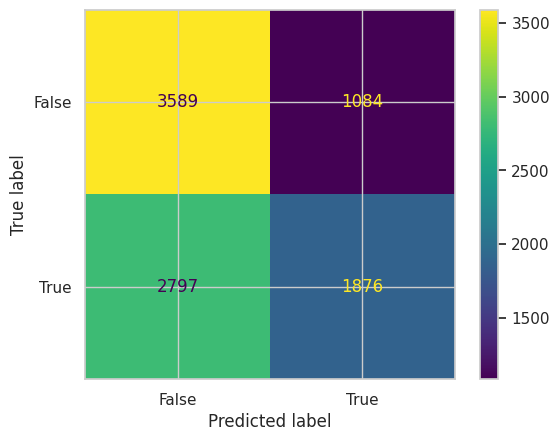

In [279]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred_LR)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

In [280]:
Specificity = metrics.recall_score(y_test, y_pred_LR, pos_label=0)
Accuracy = metrics.accuracy_score(y_test, y_pred_LR)
Precision = metrics.precision_score(y_test, y_pred_LR)
Sensitivity_recall = metrics.recall_score(y_test, y_pred_LR)
F1_score = metrics.f1_score(y_test, y_pred_LR)
print({"Accuracy":Accuracy})
print({"Precision":Precision,})
print({"Sensitivity_recall":Sensitivity_recall,})
print({"Specificity":Specificity,})
print({"F1_score":F1_score})

{'Accuracy': 0.5847421356730151}
{'Precision': 0.6337837837837837}
{'Sensitivity_recall': 0.4014551679863043}
{'Specificity': 0.7680291033597261}
{'F1_score': 0.49154984933839907}


In [281]:
X_train, y_train = get_train_batch(df3_class0, df3_class1, 0, 1482)

ETC1 = ExtraTreesClassifier()
ETC1.fit(X_train, y_train)
y_pred1_ETC = ETC1.predict(X_test)

In [282]:
X_train, y_train = get_train_batch(df3_class0, df3_class1, 1483, 2964)

ETC2 = ExtraTreesClassifier()
ETC2.fit(X_train, y_train)
y_pred2_ETC = ETC2.predict(X_test)

In [283]:
X_train, y_train = get_train_batch(df3_class0, df3_class1, 2965, 4446)

ETC3 = ExtraTreesClassifier()
ETC3.fit(X_train, y_train)
y_pred3_ETC = ETC3.predict(X_test)

In [284]:
len(y_pred1_ETC)

9346

In [285]:
y_pred_ETC = y_pred1_ETC.copy()
for i in range(len(y_pred1_ETC)):
    n_ones = y_pred1_ETC[i] + y_pred2_ETC[i] + y_pred3_ETC[i]
    if n_ones>1:
        y_pred_ETC[i] = 1
    else:
        y_pred_ETC[i] = 0

In [286]:
cl_rep_ETC = classification_report(y_test, y_pred_ETC)
print(cl_rep_ETC)

              precision    recall  f1-score   support

           0       0.72      0.80      0.76      4673
           1       0.77      0.69      0.73      4673

    accuracy                           0.74      9346
   macro avg       0.75      0.74      0.74      9346
weighted avg       0.75      0.74      0.74      9346



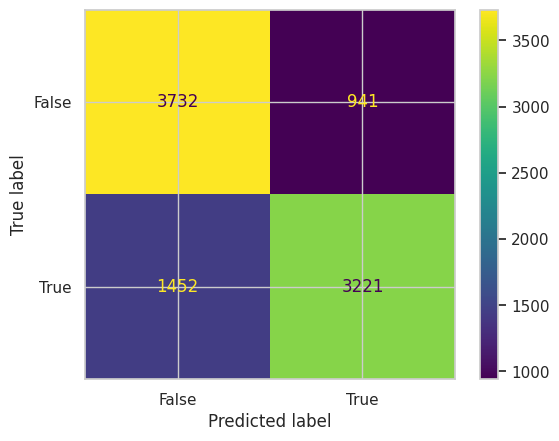

In [287]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred_ETC)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

In [288]:
Specificity = metrics.recall_score(y_test, y_pred_ETC, pos_label=0)
Accuracy = metrics.accuracy_score(y_test, y_pred_ETC)
Precision = metrics.precision_score(y_test, y_pred_ETC)
Sensitivity_recall = metrics.recall_score(y_test, y_pred_ETC)
F1_score = metrics.f1_score(y_test, y_pred_ETC)
print({"Accuracy":Accuracy})
print({"Precision":Precision,})
print({"Sensitivity_recall":Sensitivity_recall,})
print({"Specificity":Specificity,})
print({"F1_score":F1_score})

{'Accuracy': 0.7439546329980741}
{'Precision': 0.7739067755886593}
{'Sensitivity_recall': 0.689278835865611}
{'Specificity': 0.7986304301305371}
{'F1_score': 0.7291454442558007}


In [289]:
X_train, y_train = get_train_batch(df3_class0, df3_class1, 0, 1482)

DTC1 = DecisionTreeClassifier()
DTC1.fit(X_train, y_train)
y_pred1_DTC = DTC1.predict(X_test)

In [290]:
X_train, y_train = get_train_batch(df3_class0, df3_class1, 1483, 2964)

DTC2 = DecisionTreeClassifier()
DTC2.fit(X_train, y_train)
y_pred2_DTC = DTC2.predict(X_test)

In [291]:
X_train, y_train = get_train_batch(df3_class0, df3_class1, 2965, 4446)

DTC3 = DecisionTreeClassifier()
DTC3.fit(X_train, y_train)
y_pred3_DTC = DTC3.predict(X_test)

In [292]:
len(y_pred1_DTC)

9346

In [293]:
y_pred_DTC = y_pred1_DTC.copy()
for i in range(len(y_pred1_DTC)):
    n_ones = y_pred1_DTC[i] + y_pred2_DTC[i] + y_pred3_DTC[i]
    if n_ones>1:
        y_pred_DTC[i] = 1
    else:
        y_pred_DTC[i] = 0

In [294]:
cl_rep_DTC = classification_report(y_test, y_pred_DTC)
print(cl_rep_DTC)

              precision    recall  f1-score   support

           0       0.72      0.69      0.70      4673
           1       0.70      0.73      0.71      4673

    accuracy                           0.71      9346
   macro avg       0.71      0.71      0.71      9346
weighted avg       0.71      0.71      0.71      9346



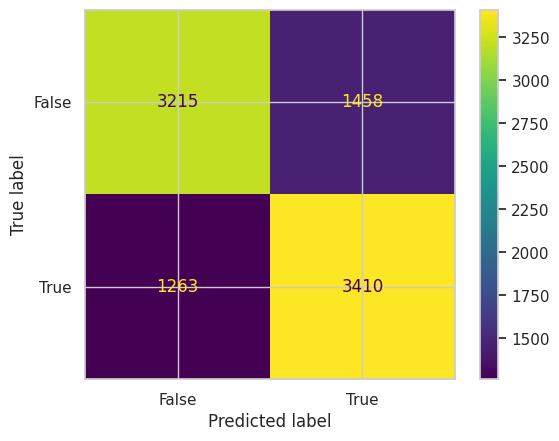

In [295]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred_DTC)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

In [296]:
Specificity = metrics.recall_score(y_test, y_pred_DTC, pos_label=0)
Accuracy = metrics.accuracy_score(y_test, y_pred_DTC)
Precision = metrics.precision_score(y_test, y_pred_DTC)
Sensitivity_recall = metrics.recall_score(y_test, y_pred_DTC)
F1_score = metrics.f1_score(y_test, y_pred_DTC)
print({"Accuracy":Accuracy})
print({"Precision":Precision,})
print({"Sensitivity_recall":Sensitivity_recall,})
print({"Specificity":Specificity,})
print({"F1_score":F1_score})

{'Accuracy': 0.708859405093088}
{'Precision': 0.700493015612161}
{'Sensitivity_recall': 0.7297239460731864}
{'Specificity': 0.6879948641129895}
{'F1_score': 0.7148097683680956}


In [297]:
# Ensemble with SMOTE

In [298]:
X = df.drop('IsDefaulter',axis='columns')
y = df['IsDefaulter']

In [299]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy='auto', random_state=42, k_neighbors=5,)
X_sm, y_sm = smote.fit_resample(X, y)

y_sm.value_counts()

,count
IsDefaulter,
1,23364
0,23364


In [300]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_sm, y_sm, test_size=0.2, random_state=15, stratify=y_sm)

In [301]:
# Number of classes in training Data
y_train.value_counts()

,count
IsDefaulter,
0,18691
1,18691


In [302]:
df3 = X_train.copy()
df3['IsDefaulter'] = y_train

In [303]:
df3.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,IsDefaulter
7090,120000,2,2,2,29,0,0,0,0,0,...,116877,117359,117029,6000,5500,4160,4120,4250,4380,0
3433,20000,1,1,2,22,0,0,0,0,0,...,18674,15452,15882,3004,3006,3007,489,2110,2201,0
6057,230000,1,1,1,44,-1,-1,-1,-1,0,...,1630,815,815,815,815,1630,0,815,629,0
46183,400952,2,1,2,32,0,0,0,0,0,...,246165,251173,251556,10450,9775,9027,8970,9208,8913,1
20013,350000,2,1,1,42,-1,2,-1,-1,-1,...,1559,1962,3683,0,27036,1559,1962,3683,3074,0


In [304]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37382 entries, 7090 to 7452
Data columns (total 24 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   LIMIT_BAL    37382 non-null  int64
 1   SEX          37382 non-null  int64
 2   EDUCATION    37382 non-null  int64
 3   MARRIAGE     37382 non-null  int64
 4   AGE          37382 non-null  int64
 5   PAY_0        37382 non-null  int64
 6   PAY_2        37382 non-null  int64
 7   PAY_3        37382 non-null  int64
 8   PAY_4        37382 non-null  int64
 9   PAY_5        37382 non-null  int64
 10  PAY_6        37382 non-null  int64
 11  BILL_AMT1    37382 non-null  int64
 12  BILL_AMT2    37382 non-null  int64
 13  BILL_AMT3    37382 non-null  int64
 14  BILL_AMT4    37382 non-null  int64
 15  BILL_AMT5    37382 non-null  int64
 16  BILL_AMT6    37382 non-null  int64
 17  PAY_AMT1     37382 non-null  int64
 18  PAY_AMT2     37382 non-null  int64
 19  PAY_AMT3     37382 non-null  int64
 20  PAY_AMT4 

In [305]:
df3_class0 = df3[df3.IsDefaulter==0]
df3_class1 = df3[df3.IsDefaulter==1]

In [306]:
def get_train_batch(df_majority, df_minority, start, end):
    df_train = pd.concat([df_majority[start:end], df_minority[start:end]], axis=0)
    X_train = df_train.drop('IsDefaulter', axis='columns')
    y_train = df_train.IsDefaulter
    return X_train, y_train

In [307]:
X_train, y_train = get_train_batch(df3_class0, df3_class1, 0, 1482)

LR1 = LogisticRegression()
LR1.fit(X_train, y_train)
y_pred1_LR = LR1.predict(X_test)

In [308]:
X_train, y_train = get_train_batch(df3_class0, df3_class1, 1483, 2964)

LR2 = LogisticRegression()
LR2.fit(X_train, y_train)
y_pred2_LR = LR2.predict(X_test)

In [309]:
X_train, y_train = get_train_batch(df3_class0, df3_class1, 2965, 4446)

LR3 = LogisticRegression()
LR3.fit(X_train, y_train)
y_pred3_LR = LR3.predict(X_test)

In [310]:
len(y_pred1_LR)

9346

In [311]:
y_pred_LR = y_pred1_LR.copy()
for i in range(len(y_pred1_LR)):
    n_ones = y_pred1_LR[i] + y_pred2_LR[i] + y_pred3_LR[i]
    if n_ones>1:
        y_pred_LR[i] = 1
    else:
        y_pred_LR[i] = 0

In [312]:
cl_rep_LR = classification_report(y_test, y_pred_LR)
print(cl_rep_LR)

              precision    recall  f1-score   support

           0       0.57      0.76      0.65      4673
           1       0.64      0.42      0.51      4673

    accuracy                           0.59      9346
   macro avg       0.60      0.59      0.58      9346
weighted avg       0.60      0.59      0.58      9346



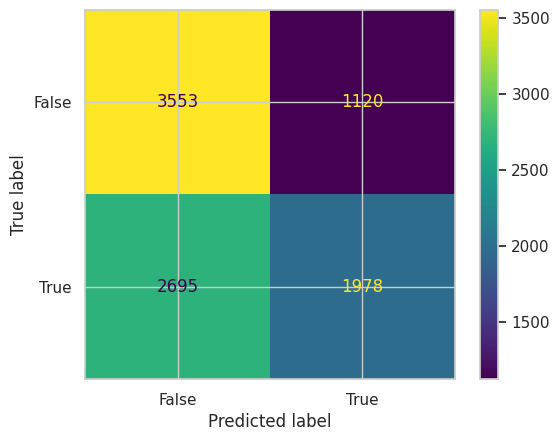

In [313]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred_LR)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

In [314]:
Specificity = metrics.recall_score(y_test, y_pred_LR, pos_label=0)
Accuracy = metrics.accuracy_score(y_test, y_pred_LR)
Precision = metrics.precision_score(y_test, y_pred_LR)
Sensitivity_recall = metrics.recall_score(y_test, y_pred_LR)
F1_score = metrics.f1_score(y_test, y_pred_LR)
print({"Accuracy":Accuracy})
print({"Precision":Precision,})
print({"Sensitivity_recall":Sensitivity_recall,})
print({"Specificity":Specificity,})
print({"F1_score":F1_score})

{'Accuracy': 0.5918039803124331}
{'Precision': 0.6384764364105875}
{'Sensitivity_recall': 0.4232826877808688}
{'Specificity': 0.7603252728439974}
{'F1_score': 0.5090721914811479}


In [315]:
X_train, y_train = get_train_batch(df3_class0, df3_class1, 0, 1482)

ETC1 = ExtraTreesClassifier()
ETC1.fit(X_train, y_train)
y_pred1_ETC = ETC1.predict(X_test)

In [316]:
X_train, y_train = get_train_batch(df3_class0, df3_class1, 1483, 2964)

ETC2 = ExtraTreesClassifier()
ETC2.fit(X_train, y_train)
y_pred2_ETC = ETC2.predict(X_test)

In [317]:
X_train, y_train = get_train_batch(df3_class0, df3_class1, 2965, 4446)

ETC3 = ExtraTreesClassifier()
ETC3.fit(X_train, y_train)
y_pred3_ETC = ETC3.predict(X_test)

In [318]:
len(y_pred1_ETC)

9346

In [319]:
y_pred_ETC = y_pred1_ETC.copy()
for i in range(len(y_pred1_ETC)):
    n_ones = y_pred1_ETC[i] + y_pred2_ETC[i] + y_pred3_ETC[i]
    if n_ones>1:
        y_pred_ETC[i] = 1
    else:
        y_pred_ETC[i] = 0

In [320]:
cl_rep_ETC = classification_report(y_test, y_pred_ETC)
print(cl_rep_ETC)

              precision    recall  f1-score   support

           0       0.77      0.79      0.78      4673
           1       0.79      0.76      0.77      4673

    accuracy                           0.78      9346
   macro avg       0.78      0.78      0.78      9346
weighted avg       0.78      0.78      0.78      9346



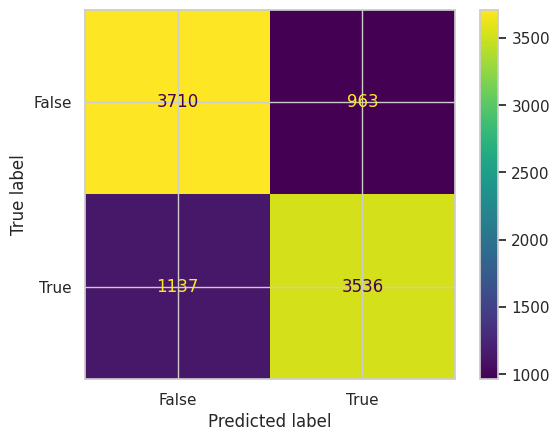

In [321]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred_ETC)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

In [322]:
Specificity = metrics.recall_score(y_test, y_pred_ETC, pos_label=0)
Accuracy = metrics.accuracy_score(y_test, y_pred_ETC)
Precision = metrics.precision_score(y_test, y_pred_ETC)
Sensitivity_recall = metrics.recall_score(y_test, y_pred_ETC)
F1_score = metrics.f1_score(y_test, y_pred_ETC)
print({"Accuracy":Accuracy})
print({"Precision":Precision,})
print({"Sensitivity_recall":Sensitivity_recall,})
print({"Specificity":Specificity,})
print({"F1_score":F1_score})

{'Accuracy': 0.7753049432912476}
{'Precision': 0.7859524338741942}
{'Sensitivity_recall': 0.7566873528782366}
{'Specificity': 0.7939225337042585}
{'F1_score': 0.7710423026602704}


In [323]:
X_train, y_train = get_train_batch(df3_class0, df3_class1, 0, 1482)

DTC1 = DecisionTreeClassifier()
DTC1.fit(X_train, y_train)
y_pred1_DTC = DTC1.predict(X_test)

In [324]:
X_train, y_train = get_train_batch(df3_class0, df3_class1, 1483, 2964)

DTC2 = DecisionTreeClassifier()
DTC2.fit(X_train, y_train)
y_pred2_DTC = DTC2.predict(X_test)

In [325]:
X_train, y_train = get_train_batch(df3_class0, df3_class1, 2965, 4446)

DTC3 = DecisionTreeClassifier()
DTC3.fit(X_train, y_train)
y_pred3_DTC = DTC3.predict(X_test)

In [326]:
len(y_pred1_DTC)

9346

In [327]:
y_pred_DTC = y_pred1_DTC.copy()
for i in range(len(y_pred1_DTC)):
    n_ones = y_pred1_DTC[i] + y_pred2_DTC[i] + y_pred3_DTC[i]
    if n_ones>1:
        y_pred_DTC[i] = 1
    else:
        y_pred_DTC[i] = 0

In [328]:
cl_rep_DTC = classification_report(y_test, y_pred_DTC)
print(cl_rep_DTC)

              precision    recall  f1-score   support

           0       0.73      0.73      0.73      4673
           1       0.73      0.73      0.73      4673

    accuracy                           0.73      9346
   macro avg       0.73      0.73      0.73      9346
weighted avg       0.73      0.73      0.73      9346



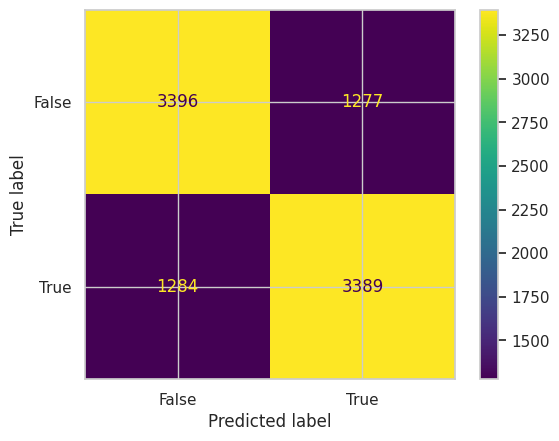

In [329]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred_DTC)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

In [330]:
Specificity = metrics.recall_score(y_test, y_pred_DTC, pos_label=0)
Accuracy = metrics.accuracy_score(y_test, y_pred_DTC)
Precision = metrics.precision_score(y_test, y_pred_DTC)
Sensitivity_recall = metrics.recall_score(y_test, y_pred_DTC)
F1_score = metrics.f1_score(y_test, y_pred_DTC)
print({"Accuracy":Accuracy})
print({"Precision":Precision,})
print({"Sensitivity_recall":Sensitivity_recall,})
print({"Specificity":Specificity,})
print({"F1_score":F1_score})

{'Accuracy': 0.7259790284613739}
{'Precision': 0.7263180454350622}
{'Sensitivity_recall': 0.7252300449390113}
{'Specificity': 0.7267280119837364}
{'F1_score': 0.7257736374344148}
